# Optimal Multi-Asset Carry Portfolios with Tail Hedging

**Question:** What is the best portfolio of carry trades, and how does tail hedging affect the portfolio?

We combine 6 FX carry pairs (AUD, GBP, CAD, EUR, CHF, MXN vs JPY) into portfolios using:
- Equal-weight
- Risk-parity (inverse volatility)
- Minimum variance (Markowitz)
- Maximum Sharpe (tangency)

Each variant is tested at 1x and 3x leverage, hedged (monthly OTM puts) and unhedged.

**Data:** Real CME futures and options from Databento (2010-2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/databento'
MONTH_CODES = {'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
               'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12}

CARRY_PAIRS = ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']

## 1. Data Loading

Copy all helper functions from multi_asset_carry.ipynb and run backtests for all 6 pairs at 1x and 3x, hedged and unhedged.

In [2]:
def load_front_month(filename):
    """Load futures data and build roll-adjusted front-month series."""
    fut = pd.read_parquet(f'{DATA_DIR}/{filename}')
    outrights = fut[~fut['symbol'].str.contains('-', na=False)].copy()
    outrights = outrights.sort_index()

    contract_prices = {}
    for _, row in outrights.iterrows():
        sym = row['symbol']
        date = row.name.normalize().tz_localize(None)
        if sym not in contract_prices:
            contract_prices[sym] = {}
        contract_prices[sym][date] = row['close']

    daily_front = {}
    for date, group in outrights.groupby(outrights.index.date):
        best = group.sort_values('volume', ascending=False).iloc[0]
        daily_front[pd.Timestamp(date)] = {
            'symbol': best['symbol'],
            'close': best['close'],
            'volume': best['volume'],
        }

    dates = sorted(daily_front.keys())
    records = []
    prev_date = None
    prev_symbol = None

    for date in dates:
        info = daily_front[date]
        cur_symbol = info['symbol']

        if prev_date is None:
            records.append({'date': date, 'close': info['close'], 'return': 0.0})
            prev_date = date
            prev_symbol = cur_symbol
            continue

        if cur_symbol == prev_symbol:
            prev_price = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            cur_price = contract_prices.get(cur_symbol, {}).get(date, 0)
            ret = cur_price / prev_price - 1 if prev_price > 0 else 0.0
        else:
            old_prev = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            old_cur = contract_prices.get(prev_symbol, {}).get(date, 0)
            ret = old_cur / old_prev - 1 if old_prev > 0 and old_cur > 0 else 0.0

        records.append({'date': date, 'close': info['close'], 'return': ret})
        prev_date = date
        prev_symbol = cur_symbol

    return pd.DataFrame(records).set_index('date')


# Load all FX futures
fx_futures = {}
pairs_files = {
    'AUD': '6A_FUT_ohlcv1d.parquet',
    'GBP': '6B_FUT_ohlcv1d.parquet',
    'CAD': '6C_FUT_ohlcv1d.parquet',
    'EUR': '6E_FUT_ohlcv1d.parquet',
    'CHF': '6S_FUT_ohlcv1d.parquet',
    'MXN': '6M_FUT_ohlcv1d.parquet',
    'JPY': '6J_FUT_ohlcv1d.parquet',
}

for ccy, filename in pairs_files.items():
    print(f'Loading {ccy} futures...')
    fx_futures[ccy] = load_front_month(filename)
    f = fx_futures[ccy]
    print(f'  {len(f)} days, {f.index.min().date()} to {f.index.max().date()}')

Loading AUD futures...


  4880 days, 2010-06-06 to 2026-02-27
Loading GBP futures...


  4880 days, 2010-06-06 to 2026-02-27
Loading CAD futures...


  4880 days, 2010-06-06 to 2026-02-27
Loading EUR futures...


  4880 days, 2010-06-06 to 2026-02-27
Loading CHF futures...


  4880 days, 2010-06-06 to 2026-02-27
Loading MXN futures...


  4877 days, 2010-06-06 to 2026-02-27
Loading JPY futures...


  4880 days, 2010-06-06 to 2026-02-27


In [3]:
# Build cross rates vs JPY
jpy = fx_futures['JPY']

cross_rates = {}
for ccy in CARRY_PAIRS:
    f = fx_futures[ccy]
    common = f.index.intersection(jpy.index)
    cross = pd.DataFrame({
        f'{ccy.lower()}_jpy': f.loc[common, 'close'] / jpy.loc[common, 'close'],
        'ccy_ret': f.loc[common, 'return'],
        'jpy_ret': jpy.loc[common, 'return'],
        'cross_ret': f.loc[common, 'return'] - jpy.loc[common, 'return'],
    }, index=common)
    cross_rates[ccy] = cross

    spot_col = f'{ccy.lower()}_jpy'
    years = (cross.index[-1] - cross.index[0]).days / 365.25
    total = cross[spot_col].iloc[-1] / cross[spot_col].iloc[0]
    cagr = total**(1/years) - 1
    print(f'{ccy}/JPY: {len(cross)} days, spot CAGR {cagr*100:.2f}%')

AUD/JPY: 4880 days, spot CAGR 2.53%
GBP/JPY: 4880 days, spot CAGR 2.99%
CAD/JPY: 4880 days, spot CAGR 1.82%
EUR/JPY: 4880 days, spot CAGR 3.38%
CHF/JPY: 4880 days, spot CAGR 6.20%
MXN/JPY: 4877 days, spot CAGR 1.65%


In [4]:
# Historical policy rates (annual averages, %)
boj_rates = {y: 0.0 for y in range(2010, 2027)}
boj_rates[2024] = 0.25
boj_rates[2025] = 0.50
boj_rates[2026] = 0.50

policy_rates = {
    'AUD': {
        2010: 4.25, 2011: 4.50, 2012: 3.50, 2013: 2.75, 2014: 2.50,
        2015: 2.00, 2016: 1.75, 2017: 1.50, 2018: 1.50, 2019: 1.00,
        2020: 0.25, 2021: 0.10, 2022: 1.85, 2023: 4.10, 2024: 4.35,
        2025: 4.35, 2026: 4.10,
    },
    'GBP': {
        2010: 0.50, 2011: 0.50, 2012: 0.50, 2013: 0.50, 2014: 0.50,
        2015: 0.50, 2016: 0.25, 2017: 0.35, 2018: 0.65, 2019: 0.75,
        2020: 0.25, 2021: 0.15, 2022: 2.00, 2023: 4.75, 2024: 5.00,
        2025: 4.50, 2026: 4.25,
    },
    'CAD': {
        2010: 0.50, 2011: 1.00, 2012: 1.00, 2013: 1.00, 2014: 1.00,
        2015: 0.75, 2016: 0.50, 2017: 0.75, 2018: 1.50, 2019: 1.75,
        2020: 0.50, 2021: 0.25, 2022: 2.50, 2023: 4.75, 2024: 4.50,
        2025: 3.25, 2026: 3.00,
    },
    'EUR': {
        2010: 1.00, 2011: 1.25, 2012: 0.75, 2013: 0.50, 2014: 0.15,
        2015: 0.05, 2016: 0.00, 2017: 0.00, 2018: 0.00, 2019: 0.00,
        2020: 0.00, 2021: 0.00, 2022: 1.25, 2023: 4.00, 2024: 4.25,
        2025: 3.15, 2026: 2.65,
    },
    'CHF': {
        2010: 0.25, 2011: 0.00, 2012: 0.00, 2013: 0.00, 2014: 0.00,
        2015: -0.75, 2016: -0.75, 2017: -0.75, 2018: -0.75, 2019: -0.75,
        2020: -0.75, 2021: -0.75, 2022: 0.25, 2023: 1.50, 2024: 1.50,
        2025: 0.50, 2026: 0.25,
    },
    'MXN': {
        2010: 4.50, 2011: 4.50, 2012: 4.50, 2013: 4.00, 2014: 3.50,
        2015: 3.25, 2016: 5.00, 2017: 7.00, 2018: 8.00, 2019: 8.00,
        2020: 5.00, 2021: 4.50, 2022: 8.50, 2023: 11.25, 2024: 10.75,
        2025: 9.50, 2026: 8.50,
    },
}

for ccy in cross_rates:
    cr = cross_rates[ccy]
    cr['ccy_rate'] = cr.index.year.map(lambda y: policy_rates[ccy].get(y, 0)) / 100
    cr['jpn_rate'] = cr.index.year.map(lambda y: boj_rates.get(y, 0)) / 100
    cr['daily_carry'] = (cr['ccy_rate'] - cr['jpn_rate']) / 365

print(f'{"Pair":>10} {"Avg carry":>10} {"2015":>7} {"2020":>7} {"2023":>7} {"2025":>7}')
print('-' * 50)
for ccy in CARRY_PAIRS:
    cr = cross_rates[ccy]
    avg = cr['daily_carry'].mean() * 365 * 100
    row = f'{ccy}/JPY:  {avg:>8.2f}%'
    for yr in [2015, 2020, 2023, 2025]:
        diff = policy_rates[ccy].get(yr, 0) - boj_rates.get(yr, 0)
        row += f' {diff:>6.2f}%'
    print(row)

      Pair  Avg carry    2015    2020    2023    2025
--------------------------------------------------
AUD/JPY:      2.43%   2.00%   0.25%   4.10%   3.85%
GBP/JPY:      1.36%   0.50%   0.25%   4.75%   4.00%
CAD/JPY:      1.59%   0.75%   0.50%   4.75%   2.75%
EUR/JPY:      0.99%   0.05%   0.00%   4.00%   2.65%
CHF/JPY:     -0.14%  -0.75%  -0.75%   1.50%   0.00%
MXN/JPY:      6.39%   3.25%   5.00%  11.25%   9.00%


In [5]:
# Strike divisors for each product
STRIKE_DIVISORS = {
    'AUD': 1000, 'GBP': 1000, 'CAD': 1000, 'EUR': 1000,
    'CHF': 1000, 'MXN': 10000, 'JPY': 100000,
}

OPT_CONFIGS = {
    'AUD': ('6A_OPT_ohlcv1d.parquet', 'ADU_OPT_ohlcv1d.parquet',
            ['6A'], ['ADU'], '2016-08-23'),
    'GBP': ('6B_OPT_ohlcv1d.parquet', 'GBU_OPT_ohlcv1d.parquet',
            ['6B'], ['GBU'], '2016-08-23'),
    'CAD': ('6C_OPT_ohlcv1d.parquet', 'CAU_OPT_ohlcv1d.parquet',
            ['6C'], ['CAU'], '2016-08-22'),
    'EUR': ('6E_OPT_ohlcv1d.parquet', 'EUU_OPT_ohlcv1d.parquet',
            ['6E'], ['EUU'], '2016-08-09'),
    'CHF': ('6S_OPT_ohlcv1d.parquet', None, ['6S'], None, None),
    'MXN': ('6M_OPT_ohlcv1d.parquet', None, ['6M'], None, None),
}


def parse_option_generic(sym, date_year, prefixes, strike_div):
    parts = sym.split()
    if len(parts) != 2:
        return None
    contract, opt = parts
    opt_type = opt[0]
    if opt_type not in ('C', 'P'):
        return None
    try:
        strike_raw = int(opt[1:])
    except ValueError:
        return None
    strike = strike_raw / strike_div

    month_code = None
    year_digit = None
    for pfx in prefixes:
        if contract.startswith(pfx):
            rest = contract[len(pfx):]
            if len(rest) >= 2:
                month_code = rest[0]
                try:
                    year_digit = int(rest[1])
                except ValueError:
                    continue
                break
    if month_code is None or year_digit is None:
        return None
    month = MONTH_CODES.get(month_code, 0)
    if month == 0:
        return None
    decade_base = (date_year // 10) * 10
    year = decade_base + year_digit
    if year < date_year - 2:
        year += 10
    return month, year, opt_type, strike


def load_fx_options_generic(ccy):
    config = OPT_CONFIGS[ccy]
    old_file, new_file, old_prefixes, new_prefixes, cutoff = config
    strike_div = STRIKE_DIVISORS[ccy]

    old = pd.read_parquet(f'{DATA_DIR}/{old_file}')
    old = old[~old['symbol'].str.contains('UD:', na=False)].copy()

    if new_file is not None:
        new = pd.read_parquet(f'{DATA_DIR}/{new_file}')
        new = new[~new['symbol'].str.contains('UD:', na=False)].copy()
        cutoff_ts = pd.Timestamp(cutoff, tz='UTC')
        old = old[old.index < cutoff_ts]
        combined = pd.concat([old, new]).sort_index()
        all_prefixes = old_prefixes + new_prefixes
    else:
        combined = old.sort_index()
        all_prefixes = old_prefixes

    records = []
    for idx, row in combined.iterrows():
        parsed = parse_option_generic(row['symbol'], idx.year, all_prefixes, strike_div)
        if parsed is None:
            continue
        month, year, opt_type, strike = parsed
        try:
            first_of_month = pd.Timestamp(year=year, month=month, day=1)
        except ValueError:
            continue
        third_wed = first_of_month + pd.offsets.WeekOfMonth(week=2, weekday=2)
        expiry = (third_wed - pd.offsets.BDay(2)).tz_localize('UTC')
        records.append({
            'date': idx, 'symbol': row['symbol'], 'opt_type': opt_type,
            'strike': strike, 'expiry': expiry,
            'close': row['close'], 'volume': row['volume'],
        })
    return pd.DataFrame(records)


fx_options = {}
for ccy in CARRY_PAIRS:
    print(f'Loading {ccy} options...')
    opts = load_fx_options_generic(ccy)
    fx_options[ccy] = opts
    puts = (opts['opt_type'] == 'P').sum()
    print(f'  {len(opts):,} total (puts: {puts:,}), '
          f'{opts["date"].min().date()} to {opts["date"].max().date()}')

Loading AUD options...


  281,447 total (puts: 150,657), 2010-06-06 to 2026-02-27
Loading GBP options...


  291,950 total (puts: 151,965), 2010-06-06 to 2026-02-27
Loading CAD options...


  209,251 total (puts: 110,536), 2010-06-06 to 2026-02-27
Loading EUR options...


  612,216 total (puts: 317,901), 2010-06-06 to 2026-02-27
Loading CHF options...


  47,067 total (puts: 22,974), 2010-06-07 to 2017-06-09
Loading MXN options...
  7,576 total (puts: 3,955), 2013-01-22 to 2026-02-27


In [6]:
def select_monthly_options(opts, front_prices, opt_type='P', otm_target=0.92):
    filtered = opts[opts['opt_type'] == opt_type].copy()
    if len(filtered) == 0:
        return pd.DataFrame()

    prices = front_prices[['close']].rename(columns={'close': 'fut_close'})
    prices.index = prices.index.tz_localize('UTC')
    filtered['date_norm'] = filtered['date'].dt.normalize()
    filtered = filtered.merge(prices, left_on='date_norm', right_index=True, how='left')
    filtered = filtered.dropna(subset=['fut_close'])
    filtered['moneyness'] = filtered['strike'] / filtered['fut_close']
    filtered['year_month'] = filtered['date'].dt.to_period('M')

    selections = []
    for ym, group in filtered.groupby('year_month'):
        first_day = group['date'].min()
        day_opts = group[group['date'] == first_day]
        if len(day_opts) == 0:
            continue
        day_opts = day_opts[day_opts['expiry'] > first_day + pd.Timedelta(days=14)]
        if len(day_opts) == 0:
            continue
        nearest_exp = day_opts['expiry'].min()
        day_opts = day_opts[day_opts['expiry'] == nearest_exp]

        if opt_type == 'P':
            day_opts = day_opts[day_opts['moneyness'] < 1.0]
        else:
            day_opts = day_opts[day_opts['moneyness'] > 1.0]
        if len(day_opts) == 0:
            continue

        day_opts = day_opts.copy()
        day_opts['dist'] = (day_opts['moneyness'] - otm_target).abs()
        candidates = day_opts.nsmallest(5, 'dist')
        best = candidates.sort_values('volume', ascending=False).iloc[0]
        if best['close'] <= 0:
            continue

        selections.append({
            'entry_date': first_day, 'symbol': best['symbol'],
            'strike': best['strike'], 'entry_price': best['close'],
            'expiry': best['expiry'], 'underlying': best['fut_close'],
            'moneyness': best['moneyness'], 'volume': best['volume'],
        })
    return pd.DataFrame(selections)


put_selections = {}
for ccy in CARRY_PAIRS:
    front = pd.DataFrame({'close': fx_futures[ccy]['close']})
    sels = select_monthly_options(fx_options[ccy], front, opt_type='P', otm_target=0.92)
    put_selections[ccy] = sels
    if len(sels) > 0:
        print(f'{ccy} puts: {len(sels)} months, '
              f'{sels["entry_date"].min().date()} to {sels["entry_date"].max().date()}, '
              f'avg moneyness {sels["moneyness"].mean():.3f}')
    else:
        print(f'{ccy} puts: no selections')

AUD puts: 182 months, 2010-06-07 to 2026-02-01, avg moneyness 0.955
GBP puts: 124 months, 2010-06-07 to 2021-02-01, avg moneyness 0.962


CAD puts: 180 months, 2010-06-06 to 2025-12-01, avg moneyness 0.974


EUR puts: 185 months, 2010-06-06 to 2026-02-01, avg moneyness 0.959
CHF puts: 81 months, 2010-06-07 to 2017-06-02, avg moneyness 0.974
MXN puts: 121 months, 2013-02-05 to 2026-02-02, avg moneyness 0.968


In [7]:
def build_settlement_lookup(opts):
    lookup = {}
    for _, row in opts.iterrows():
        sym = row['symbol']
        if sym not in lookup:
            lookup[sym] = []
        lookup[sym].append((row['date'], row['close']))
    for sym in lookup:
        lookup[sym].sort(key=lambda x: x[0])
    return lookup


def get_settlement(symbol, strike, expiry, opt_type, lookup, front_prices):
    window_start = expiry - pd.Timedelta(days=5)
    window_end = expiry + pd.Timedelta(days=2)
    if symbol in lookup:
        near = [(d, p) for d, p in lookup[symbol] if window_start <= d <= window_end]
        if near:
            return near[-1][1]
    near_dates = front_prices[
        (front_prices.index >= (expiry - pd.Timedelta(days=3)).tz_localize(None)) &
        (front_prices.index <= (expiry + pd.Timedelta(days=3)).tz_localize(None))
    ]
    if len(near_dates) > 0:
        underlying = near_dates.iloc[-1]['close']
        if opt_type == 'P':
            return max(0, strike - underlying)
        else:
            return max(0, underlying - strike)
    return 0.0


def precompute_settlements(selections, opt_type, lookup, front_prices):
    put_map = {}
    for _, row in selections.iterrows():
        settle = get_settlement(row['symbol'], row['strike'], row['expiry'],
                                opt_type, lookup, front_prices)
        entry_price = row['entry_price']
        pnl_ratio = (settle - entry_price) / entry_price if entry_price > 0 else 0
        put_map[row['entry_date']] = {
            'symbol': row['symbol'], 'strike': row['strike'],
            'entry_price': entry_price, 'settlement': settle,
            'pnl_ratio': pnl_ratio, 'moneyness': row['moneyness'],
        }
    return put_map


def run_carry_backtest(cross_df, front_prices, put_sels, all_opts,
                       leverage=1, put_budget=0.005):
    if put_budget > 0 and len(put_sels) > 0:
        lookup = build_settlement_lookup(all_opts)
        put_map = precompute_settlements(put_sels, 'P', lookup, front_prices)
    else:
        put_map = {}

    capital = 100.0
    records = []
    current_month = None

    for date in cross_df.index:
        if capital <= 0:
            records.append({'date': date, 'capital': 0, 'daily_carry': 0,
                            'daily_spot': 0, 'put_pnl': 0})
            continue
        notional = capital * leverage
        carry_income = notional * cross_df.loc[date, 'daily_carry']
        spot_pnl = notional * cross_df.loc[date, 'cross_ret']
        put_pnl = 0
        ym = pd.Timestamp(date).to_period('M')
        if ym != current_month:
            current_month = ym
            date_tz = pd.Timestamp(date, tz='UTC')
            if put_budget > 0 and date_tz in put_map:
                cost = put_budget * notional
                put_pnl = cost * put_map[date_tz]['pnl_ratio']
        capital += carry_income + spot_pnl + put_pnl
        records.append({'date': date, 'capital': capital, 'daily_carry': carry_income,
                        'daily_spot': spot_pnl, 'put_pnl': put_pnl})
    return pd.DataFrame(records).set_index('date')


empty_sels = pd.DataFrame(columns=['entry_date', 'symbol', 'strike', 'entry_price',
                                    'expiry', 'underlying', 'moneyness', 'volume'])

In [8]:
# Run backtests for all pairs x leverage x hedge
all_results = {}

for ccy in CARRY_PAIRS:
    cr = cross_rates[ccy]
    front = pd.DataFrame({'close': fx_futures[ccy]['close']})
    sels = put_selections.get(ccy, empty_sels)
    opts = fx_options.get(ccy, pd.DataFrame())
    has_hedge = len(sels) >= 12

    for lev in [1, 3]:
        print(f'Running {ccy}/JPY {lev}x unhedged...')
        all_results[(ccy, lev, False)] = run_carry_backtest(
            cr, front, empty_sels, opts, leverage=lev, put_budget=0)
        if has_hedge:
            print(f'Running {ccy}/JPY {lev}x hedged...')
            all_results[(ccy, lev, True)] = run_carry_backtest(
                cr, front, sels, opts, leverage=lev, put_budget=0.005)

print(f'\nTotal backtests: {len(all_results)}')

Running AUD/JPY 1x unhedged...


Running AUD/JPY 1x hedged...


Running AUD/JPY 3x unhedged...
Running AUD/JPY 3x hedged...


Running GBP/JPY 1x unhedged...
Running GBP/JPY 1x hedged...


Running GBP/JPY 3x unhedged...
Running GBP/JPY 3x hedged...


...

Running EUR/JPY 3x unhedged...
Running EUR/JPY 3x hedged...


Running CHF/JPY 1x unhedged...
Running CHF/JPY 1x hedged...


Running CHF/JPY 3x unhedged...
Running CHF/JPY 3x hedged...


Running MXN/JPY 1x unhedged...
Running MXN/JPY 1x hedged...
Running MXN/JPY 3x unhedged...


Running MXN/JPY 3x hedged...

Total backtests: 24


In [9]:
def compute_stats(capital_series):
    """Compute comprehensive strategy stats from capital series."""
    cap = capital_series[capital_series > 0]
    if len(cap) < 252:
        return None
    daily_ret = cap.pct_change().dropna()
    years = (cap.index[-1] - cap.index[0]).days / 365.25
    total_ret = cap.iloc[-1] / cap.iloc[0]
    ann_ret = total_ret ** (1/years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cap / cap.cummax() - 1).min()
    downside = daily_ret[daily_ret < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 1 else ann_vol
    sortino = ann_ret / downside_std if downside_std > 0 else 0
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    skew = daily_ret.skew()
    kurt = daily_ret.kurtosis()

    drawdown = cap / cap.cummax() - 1
    in_dd = drawdown < 0
    dd_groups = (~in_dd).cumsum()
    if in_dd.any():
        dd_durations = in_dd.groupby(dd_groups).sum()
        max_dd_days = int(dd_durations.max())
    else:
        max_dd_days = 0

    yearly_ret = cap.resample('YE').last().pct_change().dropna()
    pct_positive_years = (yearly_ret > 0).mean() * 100

    return {
        'CAGR': ann_ret, 'Vol': ann_vol, 'Sharpe': sharpe,
        'Sortino': sortino, 'Calmar': calmar,
        'MaxDD': max_dd, 'MaxDD_days': max_dd_days,
        'Skew': skew, 'Kurt': kurt,
        'Win%': pct_positive_years, 'Total': total_ret,
    }

## 2. Return Series Construction

Build daily return series for each pair x leverage x hedge combination. These are the inputs for all portfolio analysis.

In [10]:
# Build daily return DataFrames for each leverage x hedge combo
# Returns are from capital series (includes carry + spot + put P&L)

def get_daily_returns(results_dict, leverage, hedged):
    """Extract daily returns for all available pairs at given leverage/hedge."""
    rets = {}
    for ccy in CARRY_PAIRS:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        rets[ccy] = cap.pct_change().fillna(0)
    return pd.DataFrame(rets)

# Create return matrices
ret_1x_u = get_daily_returns(all_results, 1, False)
ret_1x_h = get_daily_returns(all_results, 1, True)
ret_3x_u = get_daily_returns(all_results, 3, False)
ret_3x_h = get_daily_returns(all_results, 3, True)

print('Return matrix shapes:')
print(f'  1x unhedged: {ret_1x_u.shape} — cols: {list(ret_1x_u.columns)}')
print(f'  1x hedged:   {ret_1x_h.shape} — cols: {list(ret_1x_h.columns)}')
print(f'  3x unhedged: {ret_3x_u.shape} — cols: {list(ret_3x_u.columns)}')
print(f'  3x hedged:   {ret_3x_h.shape} — cols: {list(ret_3x_h.columns)}')

# For portfolio construction, use the "best available" return: hedged if available, else unhedged
def get_best_returns(results_dict, leverage):
    """Get daily returns using hedged where available, unhedged otherwise."""
    rets = {}
    hedge_status = {}
    for ccy in CARRY_PAIRS:
        key_h = (ccy, leverage, True)
        key_u = (ccy, leverage, False)
        if key_h in results_dict:
            cap = results_dict[key_h]['capital']
            hedge_status[ccy] = 'hedged'
        elif key_u in results_dict:
            cap = results_dict[key_u]['capital']
            hedge_status[ccy] = 'unhedged'
        else:
            continue
        cap = cap[cap > 0]
        rets[ccy] = cap.pct_change().fillna(0)
    print(f'Hedge status: {hedge_status}')
    return pd.DataFrame(rets)

ret_1x_best = get_best_returns(all_results, 1)
ret_3x_best = get_best_returns(all_results, 3)

Return matrix shapes:
  1x unhedged: (4880, 6) — cols: ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']
  1x hedged:   (4880, 6) — cols: ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']
  3x unhedged: (4880, 6) — cols: ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']
  3x hedged:   (4880, 6) — cols: ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']
Hedge status: {'AUD': 'hedged', 'GBP': 'hedged', 'CAD': 'hedged', 'EUR': 'hedged', 'CHF': 'hedged', 'MXN': 'hedged'}
Hedge status: {'AUD': 'hedged', 'GBP': 'hedged', 'CAD': 'hedged', 'EUR': 'hedged', 'CHF': 'hedged', 'MXN': 'hedged'}


## 3. Correlation Analysis

Pairwise correlations, rolling stability, crisis-conditional correlations, and the effect of hedging on correlation structure.

In [11]:
# 3a. Full-sample pairwise correlations (daily returns, 1x unhedged)
corr_u = ret_1x_u.corr()
corr_h = ret_1x_h.corr()

print('FULL-SAMPLE CORRELATIONS — 1x Unhedged')
print('=' * 60)
header = f'{"":>8}'
for c in corr_u.columns:
    header += f' {c:>8}'
print(header)
for idx in corr_u.index:
    row = f'{idx:>8}'
    for c in corr_u.columns:
        row += f' {corr_u.loc[idx, c]:>8.3f}'
    print(row)

avg_corr_u = corr_u.where(np.triu(np.ones(corr_u.shape), k=1).astype(bool)).stack().mean()
print(f'\nAvg pairwise correlation (unhedged): {avg_corr_u:.3f}')

print('\nFULL-SAMPLE CORRELATIONS — 1x Hedged')
print('=' * 60)
header = f'{"":>8}'
for c in corr_h.columns:
    header += f' {c:>8}'
print(header)
for idx in corr_h.index:
    row = f'{idx:>8}'
    for c in corr_h.columns:
        row += f' {corr_h.loc[idx, c]:>8.3f}'
    print(row)

avg_corr_h = corr_h.where(np.triu(np.ones(corr_h.shape), k=1).astype(bool)).stack().mean()
print(f'\nAvg pairwise correlation (hedged): {avg_corr_h:.3f}')
print(f'Correlation reduction from hedging: {(avg_corr_u - avg_corr_h):.3f}')

FULL-SAMPLE CORRELATIONS — 1x Unhedged
              AUD      GBP      CAD      EUR      CHF      MXN
     AUD    1.000    0.686    0.785    0.683    0.475    0.689
     GBP    0.686    1.000    0.709    0.747    0.525    0.607
     CAD    0.785    0.709    1.000    0.706    0.505    0.723
     EUR    0.683    0.747    0.706    1.000    0.662    0.596
     CHF    0.475    0.525    0.505    0.662    1.000    0.391
     MXN    0.689    0.607    0.723    0.596    0.391    1.000

Avg pairwise correlation (unhedged): 0.633

FULL-SAMPLE CORRELATIONS — 1x Hedged
              AUD      GBP      CAD      EUR      CHF      MXN
     AUD    1.000    0.508    0.577    0.249    0.634    0.407
     GBP    0.508    1.000    0.633    0.438    0.416    0.506
     CAD    0.577    0.633    1.000    0.542    0.412    0.616
     EUR    0.249    0.438    0.542    1.000    0.182    0.391
     CHF    0.634    0.416    0.412    0.182    1.000    0.185
     MXN    0.407    0.506    0.616    0.391    0.185    1.0

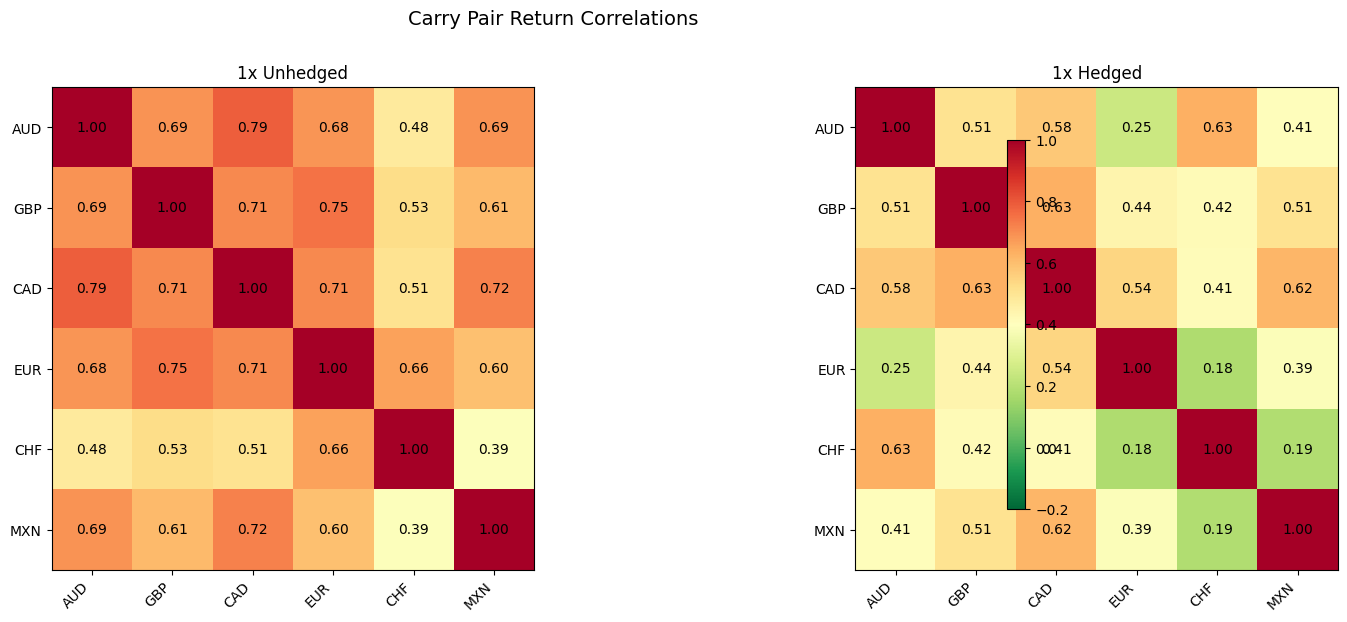

In [12]:
# Correlation heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, corr, title in [(ax1, corr_u, '1x Unhedged'), (ax2, corr_h, '1x Hedged')]:
    im = ax.imshow(corr.values, cmap='RdYlGn_r', vmin=-0.2, vmax=1.0)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
    ax.set_title(title)

plt.colorbar(im, ax=[ax1, ax2], shrink=0.8)
plt.suptitle('Carry Pair Return Correlations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

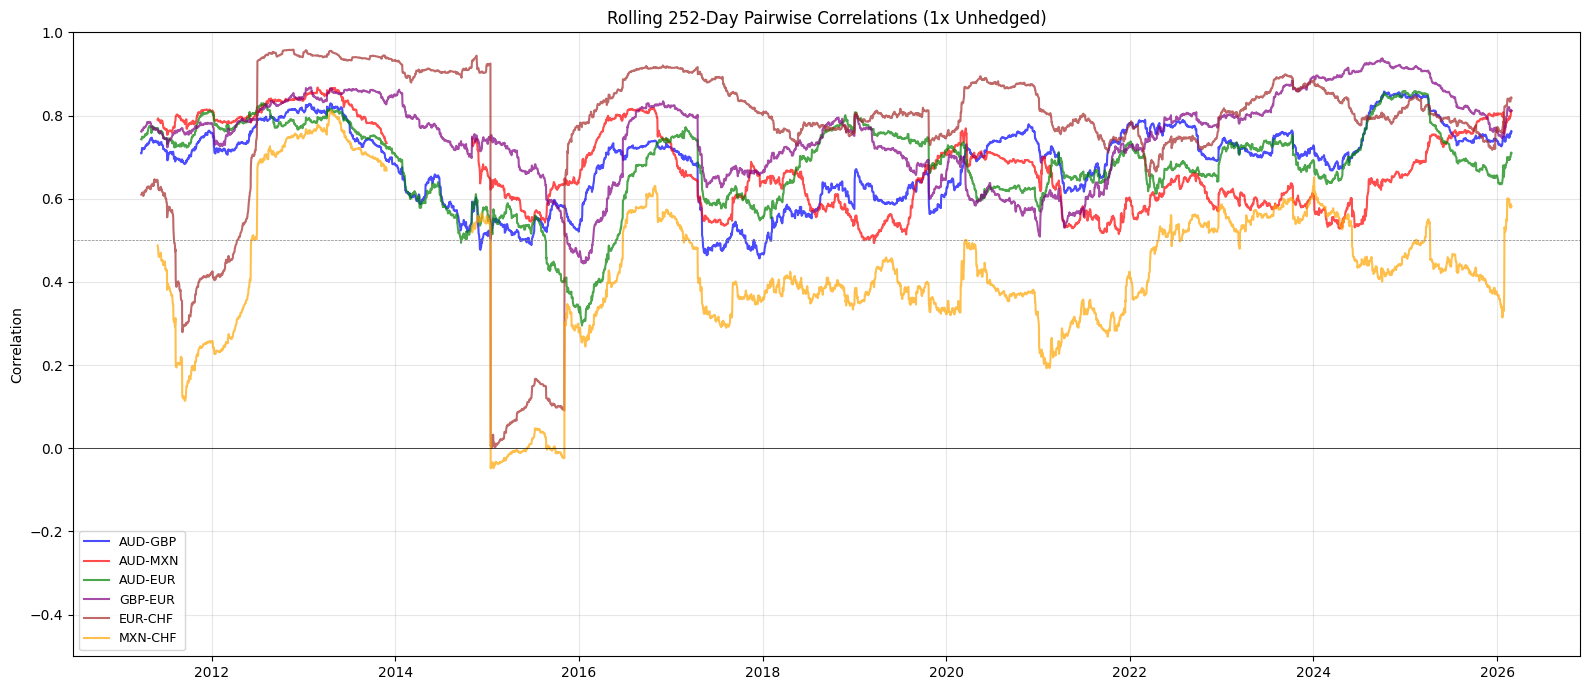

Rolling Correlation Statistics (252-day window):
        Pair     Mean      Std      Min      Max
--------------------------------------------------
     AUD-GBP    0.684    0.095    0.456    0.858
     AUD-MXN    0.671    0.098    0.493    0.867
     AUD-EUR    0.680    0.103    0.295    0.859
     GBP-EUR    0.749    0.104    0.444    0.937
     EUR-CHF    0.764    0.201    0.000    0.958
     MXN-CHF    0.425    0.173   -0.048    0.811


In [13]:
# 3b. Rolling 252-day correlations
# Pick key pairs to track
key_pairs = [('AUD', 'GBP'), ('AUD', 'MXN'), ('AUD', 'EUR'),
             ('GBP', 'EUR'), ('EUR', 'CHF'), ('MXN', 'CHF')]

fig, ax = plt.subplots(1, 1, figsize=(16, 7))
colors_roll = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for (c1, c2), color in zip(key_pairs, colors_roll):
    if c1 in ret_1x_u.columns and c2 in ret_1x_u.columns:
        rolling_corr = ret_1x_u[c1].rolling(252).corr(ret_1x_u[c2])
        ax.plot(rolling_corr.index, rolling_corr, color=color, alpha=0.7,
                label=f'{c1}-{c2}')

ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(0.5, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Rolling 252-Day Pairwise Correlations (1x Unhedged)')
ax.set_ylabel('Correlation')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 1.0)
plt.tight_layout()
plt.show()

# Summary stats on rolling correlations
print('Rolling Correlation Statistics (252-day window):')
print(f'{"Pair":>12} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 50)
for c1, c2 in key_pairs:
    if c1 in ret_1x_u.columns and c2 in ret_1x_u.columns:
        rc = ret_1x_u[c1].rolling(252).corr(ret_1x_u[c2]).dropna()
        print(f'{c1+"-"+c2:>12} {rc.mean():>8.3f} {rc.std():>8.3f} {rc.min():>8.3f} {rc.max():>8.3f}')

In [14]:
# 3c. Crisis-conditional correlations
# Define "drawdown" as periods when the equal-weight carry portfolio is in >5% drawdown

ew_cap = ret_1x_u.mean(axis=1).add(1).cumprod()
ew_dd = ew_cap / ew_cap.cummax() - 1
crisis_mask = ew_dd < -0.05
normal_mask = ~crisis_mask

corr_crisis = ret_1x_u[crisis_mask].corr()
corr_normal = ret_1x_u[normal_mask].corr()

print(f'Crisis days (EW drawdown > 5%): {crisis_mask.sum()} ({crisis_mask.mean()*100:.1f}%)')
print(f'Normal days: {normal_mask.sum()} ({normal_mask.mean()*100:.1f}%)')

avg_crisis = corr_crisis.where(np.triu(np.ones(corr_crisis.shape), k=1).astype(bool)).stack().mean()
avg_normal = corr_normal.where(np.triu(np.ones(corr_normal.shape), k=1).astype(bool)).stack().mean()

print(f'\nAvg pairwise correlation — normal periods: {avg_normal:.3f}')
print(f'Avg pairwise correlation — crisis periods:  {avg_crisis:.3f}')
print(f'Correlation increase in crises: +{avg_crisis - avg_normal:.3f}')

print('\nCRISIS-CONDITIONAL CORRELATIONS:')
header = f'{"":>8}'
for c in corr_crisis.columns:
    header += f' {c:>8}'
print(header)
for idx in corr_crisis.index:
    row = f'{idx:>8}'
    for c in corr_crisis.columns:
        row += f' {corr_crisis.loc[idx, c]:>8.3f}'
    print(row)

Crisis days (EW drawdown > 5%): 2527 (51.8%)
Normal days: 2353 (48.2%)

Avg pairwise correlation — normal periods: 0.628
Avg pairwise correlation — crisis periods:  0.642
Correlation increase in crises: +0.014

CRISIS-CONDITIONAL CORRELATIONS:
              AUD      GBP      CAD      EUR      CHF      MXN
     AUD    1.000    0.686    0.800    0.691    0.495    0.705
     GBP    0.686    1.000    0.698    0.732    0.562    0.580
     CAD    0.800    0.698    1.000    0.702    0.546    0.722
     EUR    0.691    0.732    0.702    1.000    0.744    0.569
     CHF    0.495    0.562    0.546    0.744    1.000    0.397
     MXN    0.705    0.580    0.722    0.569    0.397    1.000


In [15]:
# 3d. Do puts decorrelate returns?
# Compare correlation of hedged returns vs unhedged returns
hedged_pairs = [c for c in ret_1x_h.columns]
print(f'Pairs with hedged returns: {hedged_pairs}')

if len(hedged_pairs) >= 2:
    corr_h_sub = ret_1x_h[hedged_pairs].corr()
    corr_u_sub = ret_1x_u[hedged_pairs].corr()

    print('\nCorrelation comparison (hedged pairs only):')
    print(f'{"Pair":>12} {"Unhedged":>10} {"Hedged":>10} {"Change":>10}')
    print('-' * 45)
    for i, c1 in enumerate(hedged_pairs):
        for c2 in hedged_pairs[i+1:]:
            cu = corr_u_sub.loc[c1, c2]
            ch = corr_h_sub.loc[c1, c2]
            print(f'{c1+"-"+c2:>12} {cu:>10.3f} {ch:>10.3f} {ch-cu:>+10.3f}')

Pairs with hedged returns: ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']

Correlation comparison (hedged pairs only):
        Pair   Unhedged     Hedged     Change
---------------------------------------------
     AUD-GBP      0.686      0.508     -0.178
     AUD-CAD      0.785      0.577     -0.208
     AUD-EUR      0.683      0.249     -0.434
     AUD-CHF      0.475      0.634     +0.158
     AUD-MXN      0.689      0.407     -0.282
     GBP-CAD      0.709      0.633     -0.076
     GBP-EUR      0.747      0.438     -0.309
     GBP-CHF      0.525      0.416     -0.109
     GBP-MXN      0.607      0.506     -0.101
     CAD-EUR      0.706      0.542     -0.165
     CAD-CHF      0.505      0.412     -0.094
     CAD-MXN      0.723      0.616     -0.107
     EUR-CHF      0.662      0.182     -0.480
     EUR-MXN      0.596      0.391     -0.205
     CHF-MXN      0.391      0.185     -0.206


## 4. Equal-Weight Portfolios

Build multiple equal-weight portfolio variants:
- All 6 pairs
- Core (AUD + GBP + CAD): high carry, good puts
- High carry (AUD + MXN): highest carry pairs
- Diversified (AUD + EUR + CHF + MXN): max diversification

In [16]:
def build_ew_portfolio(results_dict, pairs, leverage, hedged):
    """Build equal-weight portfolio, NaN-aware for late-starting pairs."""
    daily_rets = {}
    for ccy in pairs:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            key = (ccy, leverage, False)  # fall back to unhedged
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        daily_rets[ccy] = cap.pct_change().fillna(0)

    if not daily_rets:
        return None

    ret_df = pd.DataFrame(daily_rets)
    # NaN-aware: average only over available pairs each day
    port_ret = ret_df.mean(axis=1)
    capital = (1 + port_ret).cumprod() * 100
    return capital


# Define portfolio variants
portfolio_configs = {
    'All-6 EW': CARRY_PAIRS,
    'Core (AUD+GBP+CAD)': ['AUD', 'GBP', 'CAD'],
    'High-Carry (AUD+MXN)': ['AUD', 'MXN'],
    'Diversified (AUD+EUR+CHF+MXN)': ['AUD', 'EUR', 'CHF', 'MXN'],
}

ew_results = {}
for name, pairs_list in portfolio_configs.items():
    for lev in [1, 3]:
        for hedged in [False, True]:
            tag = f'{name} {lev}x {"H" if hedged else "U"}'
            cap = build_ew_portfolio(all_results, pairs_list, lev, hedged)
            if cap is not None and len(cap) > 252:
                ew_results[tag] = cap

print(f'Built {len(ew_results)} equal-weight portfolio variants')

Built 16 equal-weight portfolio variants


In [17]:
# Stats table for all EW portfolios
print('=' * 140)
print('EQUAL-WEIGHT PORTFOLIOS — FULL STATS')
print('=' * 140)
print(f'{"Portfolio":>38} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
print('-' * 140)

for tag in sorted(ew_results.keys()):
    s = compute_stats(ew_results[tag])
    if s:
        print(f'{tag:>38} {s["CAGR"]*100:>7.2f}% {s["Vol"]*100:>5.1f}% '
              f'{s["Sharpe"]:>7.3f} {s["Sortino"]:>8.3f} {s["Calmar"]:>7.3f} '
              f'{s["MaxDD"]*100:>6.1f}% {s["MaxDD_days"]:>7d} '
              f'{s["Skew"]:>6.2f} {s["Kurt"]:>6.1f} {s["Total"]:>6.1f}x')

EQUAL-WEIGHT PORTFOLIOS — FULL STATS
                             Portfolio     CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD DD days   Skew   Kurt   Total
--------------------------------------------------------------------------------------------------------------------------------------------
                         All-6 EW 1x H   10.45%  11.1%   0.939    1.598   0.431  -24.2%    1768   9.47  314.0    4.8x
                         All-6 EW 1x U    6.72%   8.8%   0.763    1.034   0.260  -25.9%    2135  -0.28    4.9    2.8x
                         All-6 EW 3x H   29.39%  33.4%   0.881    1.498   0.496  -59.3%    1967   9.47  314.0   57.5x
                         All-6 EW 3x U   18.10%  26.4%   0.685    0.928   0.291  -62.2%    2271  -0.28    4.9   13.7x
               Core (AUD+GBP+CAD) 1x H   10.25%  12.2%   0.838    1.466   0.415  -24.7%    1604   9.80  308.6    4.6x
               Core (AUD+GBP+CAD) 1x U    5.50%   9.3%   0.590    0.797   0.207  -26.5%    2268  -0.33    4.9    2

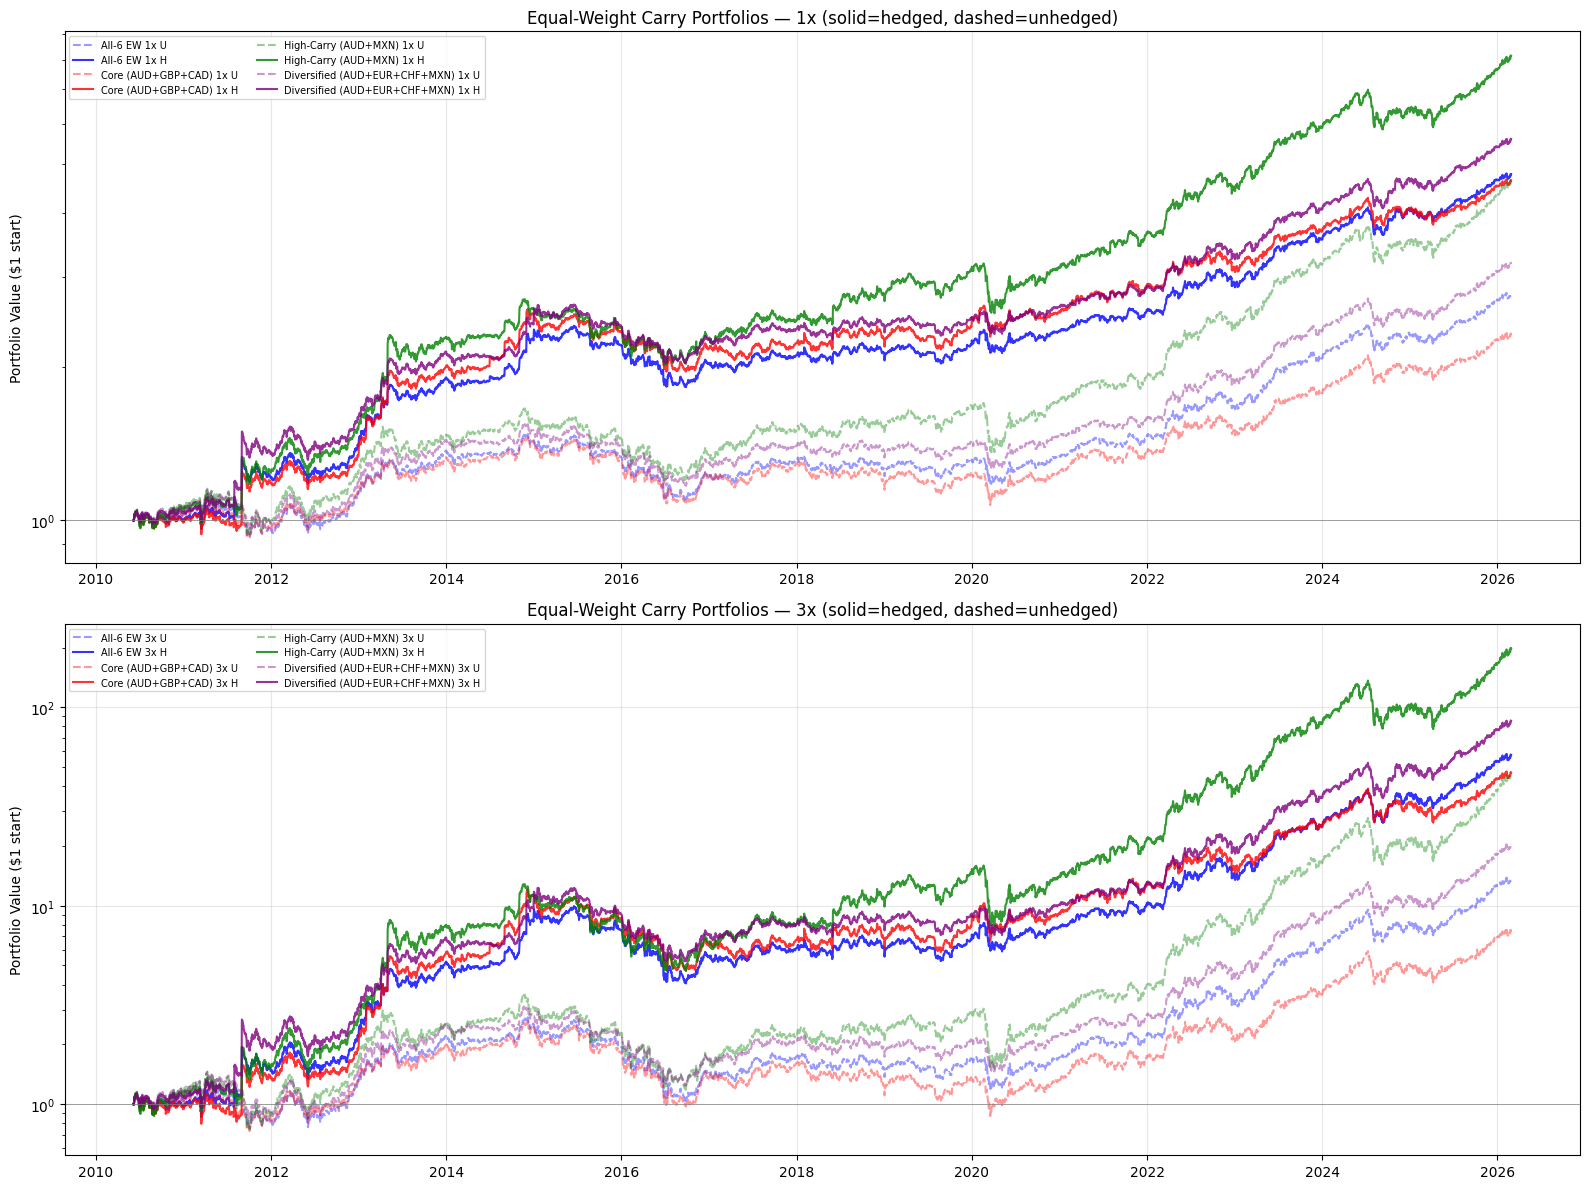

In [18]:
# Plot EW portfolio equity curves — 3x hedged variants
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

colors_ew = {'All-6 EW': 'blue', 'Core (AUD+GBP+CAD)': 'red',
             'High-Carry (AUD+MXN)': 'green', 'Diversified (AUD+EUR+CHF+MXN)': 'purple'}

for name in portfolio_configs:
    for lev, ax in [(1, ax1), (3, ax2)]:
        for hedged, ls in [('U', '--'), ('H', '-')]:
            tag = f'{name} {lev}x {hedged}'
            if tag in ew_results:
                cap = ew_results[tag] / 100
                ax.plot(cap.index, cap, color=colors_ew[name], linestyle=ls,
                        alpha=0.8 if hedged == 'H' else 0.4, label=tag, linewidth=1.5)

for ax, lev in [(ax1, '1x'), (ax2, '3x')]:
    ax.set_title(f'Equal-Weight Carry Portfolios — {lev} (solid=hedged, dashed=unhedged)')
    ax.set_ylabel('Portfolio Value ($1 start)')
    ax.legend(loc='upper left', fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.axhline(1, color='gray', linewidth=0.5)
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 5. Risk-Parity Portfolios

Weight inversely proportional to trailing 60-day realized volatility. Rebalance monthly.
This underweights volatile pairs (MXN) and overweights stable ones (EUR, CHF).

In [19]:
def build_risk_parity_portfolio(results_dict, pairs, leverage, hedged,
                                vol_window=60, rebal_freq='ME'):
    """Build risk-parity (inverse vol) portfolio with monthly rebalancing."""
    daily_rets = {}
    for ccy in pairs:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            key = (ccy, leverage, False)
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        daily_rets[ccy] = cap.pct_change().fillna(0)

    if not daily_rets:
        return None, None

    ret_df = pd.DataFrame(daily_rets)

    # Trailing volatility
    trailing_vol = ret_df.rolling(vol_window).std() * np.sqrt(252)

    # Monthly rebalance dates
    rebal_dates = ret_df.resample(rebal_freq).last().index

    # Build weighted returns
    weights_history = []
    port_rets = []

    current_weights = None
    for date in ret_df.index:
        if date in rebal_dates or current_weights is None:
            # Compute inverse-vol weights
            vol_row = trailing_vol.loc[:date].iloc[-1] if date in trailing_vol.index else None
            if vol_row is not None and vol_row.notna().sum() >= 2:
                inv_vol = 1.0 / vol_row.replace(0, np.nan)
                inv_vol = inv_vol.dropna()
                if len(inv_vol) > 0:
                    current_weights = inv_vol / inv_vol.sum()
                    weights_history.append({'date': date, **current_weights.to_dict()})

        if current_weights is not None:
            day_ret = ret_df.loc[date]
            # Weighted return (only over pairs with weights)
            common = current_weights.index.intersection(day_ret.dropna().index)
            if len(common) > 0:
                w = current_weights[common]
                w = w / w.sum()  # renormalize
                pr = (day_ret[common] * w).sum()
                port_rets.append({'date': date, 'return': pr})

    if not port_rets:
        return None, None

    port_df = pd.DataFrame(port_rets).set_index('date')
    capital = (1 + port_df['return']).cumprod() * 100
    weights_df = pd.DataFrame(weights_history).set_index('date') if weights_history else None
    return capital, weights_df


# Build risk-parity portfolios
rp_results = {}
rp_weights = {}

for lev in [1, 3]:
    for hedged in [False, True]:
        tag = f'RP All-6 {lev}x {"H" if hedged else "U"}'
        cap, wts = build_risk_parity_portfolio(
            all_results, CARRY_PAIRS, lev, hedged)
        if cap is not None and len(cap) > 252:
            rp_results[tag] = cap
            rp_weights[tag] = wts

        # Core pairs
        tag_core = f'RP Core {lev}x {"H" if hedged else "U"}'
        cap_c, wts_c = build_risk_parity_portfolio(
            all_results, ['AUD', 'GBP', 'CAD'], lev, hedged)
        if cap_c is not None and len(cap_c) > 252:
            rp_results[tag_core] = cap_c
            rp_weights[tag_core] = wts_c

print(f'Built {len(rp_results)} risk-parity portfolios')

Built 8 risk-parity portfolios


In [20]:
# Risk-parity stats
print('=' * 140)
print('RISK-PARITY PORTFOLIOS — FULL STATS')
print('=' * 140)
print(f'{"Portfolio":>30} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
print('-' * 140)

for tag in sorted(rp_results.keys()):
    s = compute_stats(rp_results[tag])
    if s:
        print(f'{tag:>30} {s["CAGR"]*100:>7.2f}% {s["Vol"]*100:>5.1f}% '
              f'{s["Sharpe"]:>7.3f} {s["Sortino"]:>8.3f} {s["Calmar"]:>7.3f} '
              f'{s["MaxDD"]*100:>6.1f}% {s["MaxDD_days"]:>7d} '
              f'{s["Skew"]:>6.2f} {s["Kurt"]:>6.1f} {s["Total"]:>6.1f}x')

# Compare RP vs EW
print('\n' + '=' * 100)
print('RISK-PARITY vs EQUAL-WEIGHT COMPARISON (All-6, 3x)')
print('=' * 100)
for hedge_label in ['H', 'U']:
    ew_tag = f'All-6 EW 3x {hedge_label}'
    rp_tag = f'RP All-6 3x {hedge_label}'
    s_ew = compute_stats(ew_results.get(ew_tag, pd.Series(dtype=float))) if ew_tag in ew_results else None
    s_rp = compute_stats(rp_results.get(rp_tag, pd.Series(dtype=float))) if rp_tag in rp_results else None
    if s_ew and s_rp:
        label = 'Hedged' if hedge_label == 'H' else 'Unhedged'
        print(f'\n{label}:')
        print(f'  EW:  CAGR {s_ew["CAGR"]*100:.2f}%, Sharpe {s_ew["Sharpe"]:.3f}, MaxDD {s_ew["MaxDD"]*100:.1f}%')
        print(f'  RP:  CAGR {s_rp["CAGR"]*100:.2f}%, Sharpe {s_rp["Sharpe"]:.3f}, MaxDD {s_rp["MaxDD"]*100:.1f}%')

RISK-PARITY PORTFOLIOS — FULL STATS
                     Portfolio     CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD DD days   Skew   Kurt   Total
--------------------------------------------------------------------------------------------------------------------------------------------
                 RP All-6 1x H    9.10%   9.9%   0.922    1.447   0.368  -24.7%    2097   3.82   78.9    3.9x
                 RP All-6 1x U    6.13%   8.5%   0.724    0.981   0.232  -26.4%    2271  -0.28    5.3    2.5x
                 RP All-6 3x H   25.49%  29.6%   0.861    1.351   0.426  -59.8%    2119   3.82   78.9   34.1x
                 RP All-6 3x U   16.39%  25.4%   0.646    0.875   0.261  -62.8%    2331  -0.28    5.3   10.6x
                  RP Core 1x H    9.51%  11.4%   0.837    1.374   0.388  -24.5%    1932   6.21  164.5    4.1x
                  RP Core 1x U    5.29%   9.2%   0.576    0.778   0.198  -26.7%    2278  -0.33    5.1    2.2x
                  RP Core 3x H   25.70%  34.1%   0.75

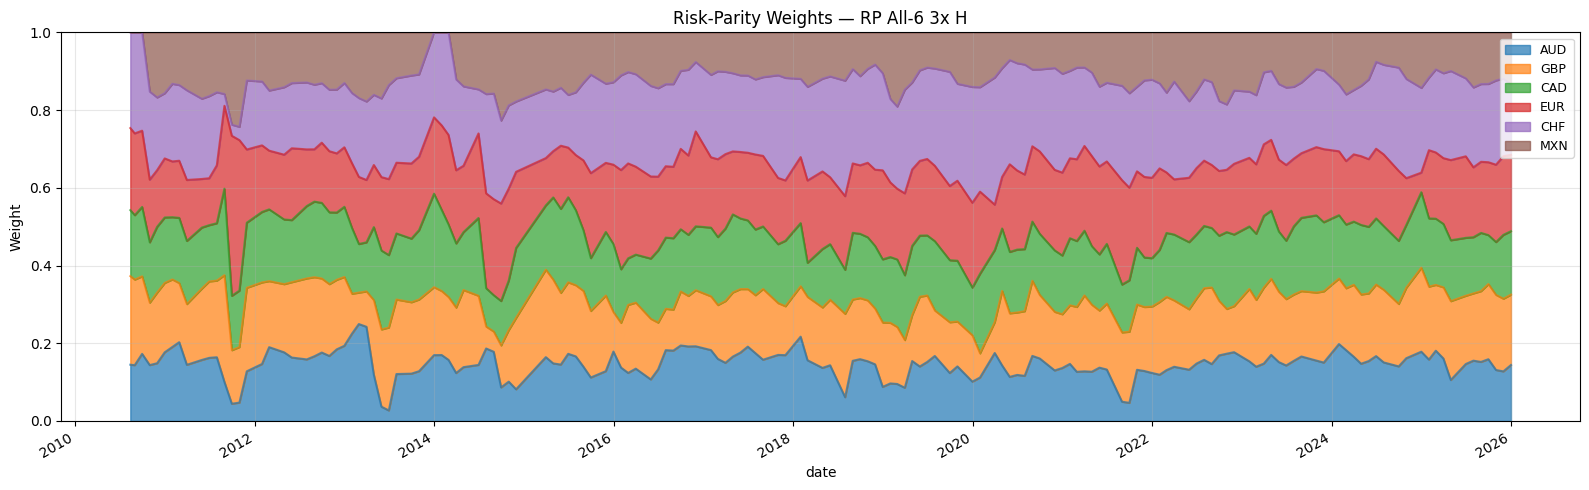

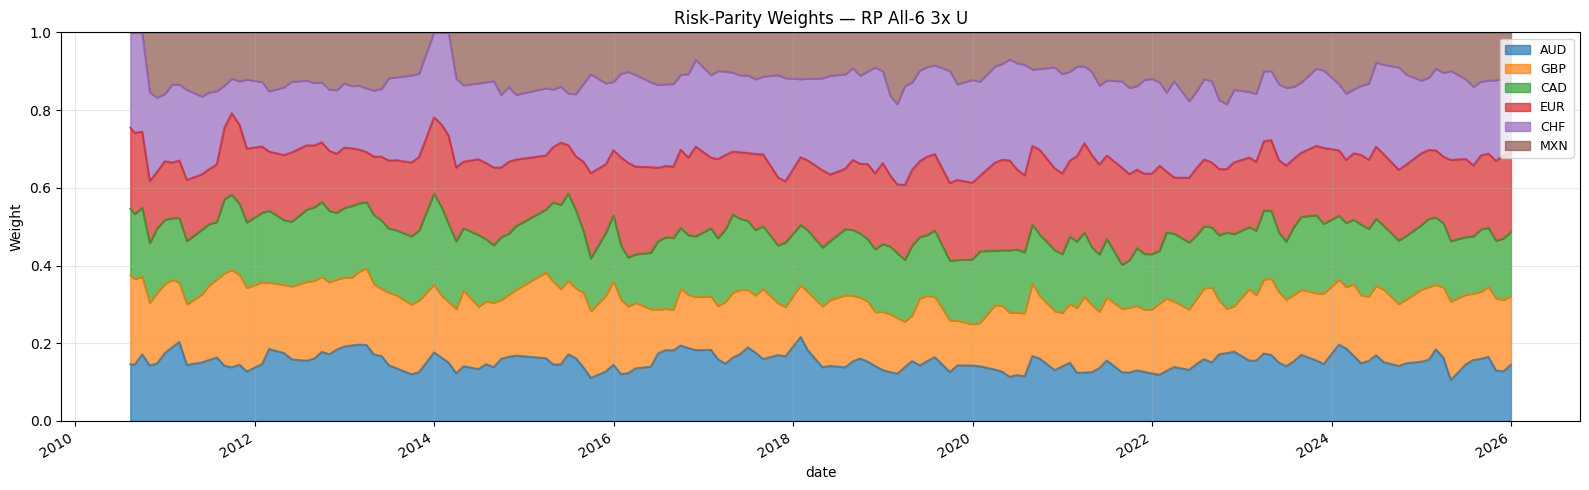

In [21]:
# Plot risk-parity weights over time
for tag in ['RP All-6 3x H', 'RP All-6 3x U']:
    if tag in rp_weights and rp_weights[tag] is not None:
        wts = rp_weights[tag]
        fig, ax = plt.subplots(1, 1, figsize=(16, 5))
        wts.plot.area(ax=ax, alpha=0.7)
        ax.set_title(f'Risk-Parity Weights — {tag}')
        ax.set_ylabel('Weight')
        ax.legend(loc='upper right', fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 6. Minimum Variance Portfolio

Full Markowitz minimum-variance with no-short constraint, using trailing 252-day covariance.
Rebalance monthly. Solved analytically with numpy (no cvxpy needed).

In [22]:
def solve_min_variance(cov_matrix, max_iter=1000):
    """Solve minimum variance portfolio with long-only constraint.
    Uses iterative projection: start equal-weight, gradient descent, project to simplex.
    """
    n = cov_matrix.shape[0]
    if n == 0:
        return np.array([])

    # Check for valid covariance matrix
    if np.any(np.isnan(cov_matrix)) or np.any(np.isinf(cov_matrix)):
        return np.ones(n) / n

    w = np.ones(n) / n
    lr = 0.5

    for _ in range(max_iter):
        grad = 2 * cov_matrix @ w
        w_new = w - lr * grad
        # Project onto simplex (long-only, sum=1)
        w_new = np.maximum(w_new, 0)
        s = w_new.sum()
        if s > 0:
            w_new = w_new / s
        else:
            w_new = np.ones(n) / n
        if np.max(np.abs(w_new - w)) < 1e-8:
            break
        w = w_new

    return w


def build_min_variance_portfolio(results_dict, pairs, leverage, hedged,
                                  cov_window=252, rebal_freq='ME'):
    """Build minimum-variance portfolio with monthly rebalancing."""
    daily_rets = {}
    for ccy in pairs:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            key = (ccy, leverage, False)
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        daily_rets[ccy] = cap.pct_change().fillna(0)

    if not daily_rets:
        return None, None

    ret_df = pd.DataFrame(daily_rets)
    rebal_dates = ret_df.resample(rebal_freq).last().index

    weights_history = []
    port_rets = []
    current_weights = None

    for date in ret_df.index:
        if date in rebal_dates or current_weights is None:
            # Get trailing returns for available pairs
            lookback = ret_df.loc[:date].tail(cov_window)
            available = lookback.dropna(axis=1, how='all')
            available = available.loc[:, available.notna().sum() >= cov_window // 2]

            if available.shape[1] >= 2:
                cov = available.cov().values
                cols = list(available.columns)
                w = solve_min_variance(cov)
                current_weights = pd.Series(w, index=cols)
                weights_history.append({'date': date, **current_weights.to_dict()})

        if current_weights is not None:
            day_ret = ret_df.loc[date]
            common = current_weights.index.intersection(day_ret.dropna().index)
            if len(common) > 0:
                ww = current_weights[common]
                ww = ww / ww.sum()
                pr = (day_ret[common] * ww).sum()
                port_rets.append({'date': date, 'return': pr})

    if not port_rets:
        return None, None

    port_df = pd.DataFrame(port_rets).set_index('date')
    capital = (1 + port_df['return']).cumprod() * 100
    weights_df = pd.DataFrame(weights_history).set_index('date') if weights_history else None
    return capital, weights_df


# Build min-variance portfolios
mv_results = {}
mv_weights = {}

for lev in [1, 3]:
    for hedged in [False, True]:
        tag = f'MinVar All-6 {lev}x {"H" if hedged else "U"}'
        cap, wts = build_min_variance_portfolio(
            all_results, CARRY_PAIRS, lev, hedged)
        if cap is not None and len(cap) > 252:
            mv_results[tag] = cap
            mv_weights[tag] = wts

print(f'Built {len(mv_results)} min-variance portfolios')

Built 4 min-variance portfolios


In [23]:
# Min-variance stats
print('=' * 140)
print('MINIMUM VARIANCE PORTFOLIOS — FULL STATS')
print('=' * 140)
print(f'{"Portfolio":>30} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
print('-' * 140)

for tag in sorted(mv_results.keys()):
    s = compute_stats(mv_results[tag])
    if s:
        print(f'{tag:>30} {s["CAGR"]*100:>7.2f}% {s["Vol"]*100:>5.1f}% '
              f'{s["Sharpe"]:>7.3f} {s["Sortino"]:>8.3f} {s["Calmar"]:>7.3f} '
              f'{s["MaxDD"]*100:>6.1f}% {s["MaxDD_days"]:>7d} '
              f'{s["Skew"]:>6.2f} {s["Kurt"]:>6.1f} {s["Total"]:>6.1f}x')

MINIMUM VARIANCE PORTFOLIOS — FULL STATS
                     Portfolio     CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD DD days   Skew   Kurt   Total
--------------------------------------------------------------------------------------------------------------------------------------------
             MinVar All-6 1x H   10.57%  10.6%   0.993    1.633   0.435  -24.3%    1781   6.58  179.1    4.7x
             MinVar All-6 1x U    6.77%   8.7%   0.783    1.056   0.263  -25.8%    2261  -0.32    5.0    2.7x
             MinVar All-6 3x H   29.98%  33.8%   0.886    1.632   0.526  -57.0%    2164   9.32  222.8   55.7x
             MinVar All-6 3x U   14.34%  24.4%   0.588    0.787   0.234  -61.3%    2414  -0.36    6.1    7.8x


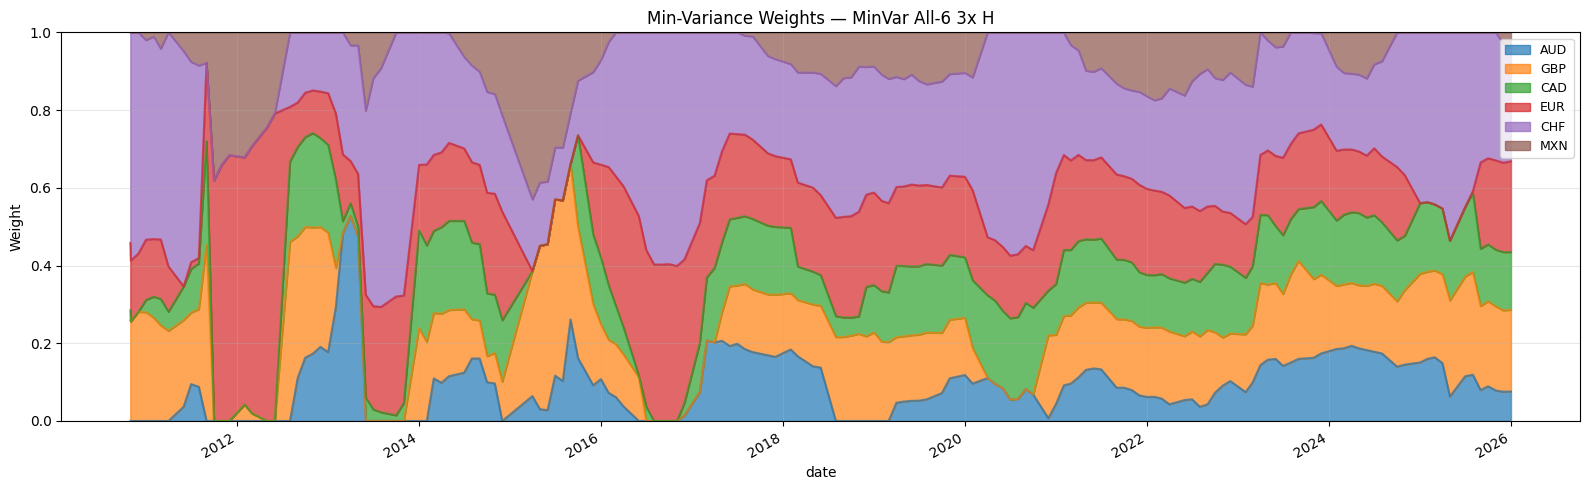

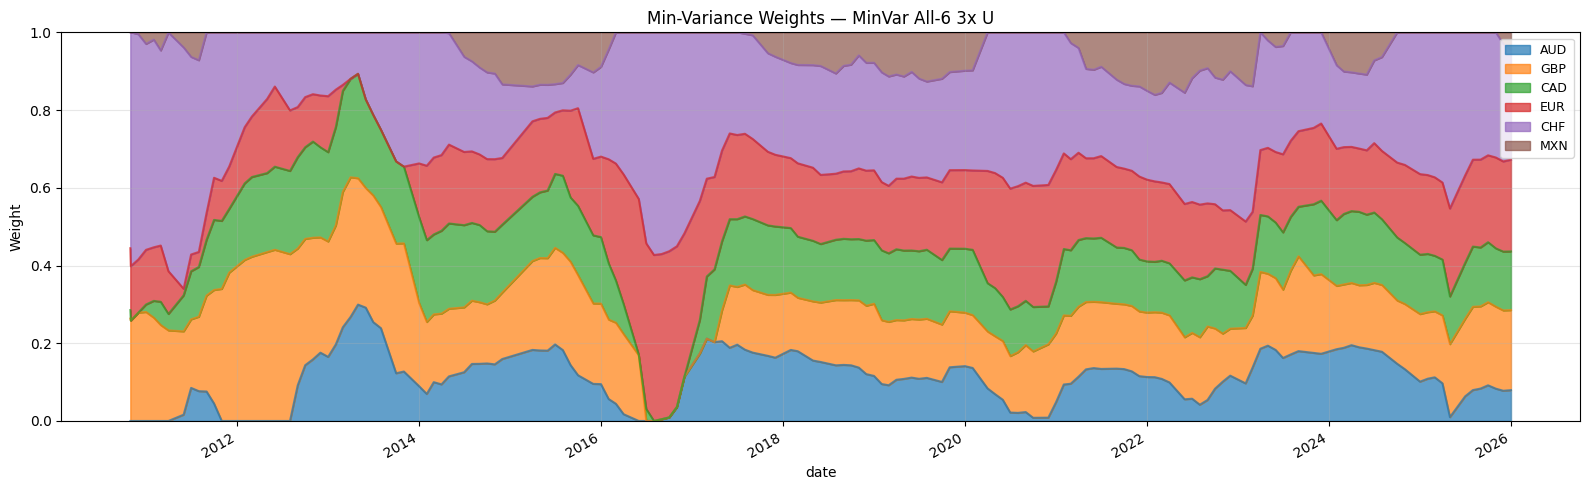

In [24]:
# Plot min-variance weights evolution
for tag in ['MinVar All-6 3x H', 'MinVar All-6 3x U']:
    if tag in mv_weights and mv_weights[tag] is not None:
        wts = mv_weights[tag].fillna(0)
        fig, ax = plt.subplots(1, 1, figsize=(16, 5))
        wts.plot.area(ax=ax, alpha=0.7)
        ax.set_title(f'Min-Variance Weights — {tag}')
        ax.set_ylabel('Weight')
        ax.legend(loc='upper right', fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 7. Maximum Sharpe Portfolio (Tangency)

Mean-variance optimization targeting maximum Sharpe ratio using trailing 252-day returns and covariance.
Rebalanced quarterly to reduce turnover from noisy mean estimates.

In [25]:
def solve_max_sharpe(mean_ret, cov_matrix, rf=0.0, max_iter=2000):
    """Solve max-Sharpe portfolio with long-only constraint.
    Uses iterative gradient ascent on Sharpe ratio.
    """
    n = len(mean_ret)
    if n == 0:
        return np.array([])

    if np.any(np.isnan(cov_matrix)) or np.any(np.isinf(cov_matrix)):
        return np.ones(n) / n

    excess = mean_ret - rf
    w = np.ones(n) / n
    lr = 0.3

    for _ in range(max_iter):
        port_ret = w @ excess
        port_var = w @ cov_matrix @ w
        port_vol = np.sqrt(max(port_var, 1e-12))

        # Gradient of Sharpe = (vol * d_ret - ret * d_vol) / vol^2
        d_ret = excess
        d_var = 2 * cov_matrix @ w
        d_vol = d_var / (2 * port_vol)
        grad = (port_vol * d_ret - port_ret * d_vol) / (port_var + 1e-12)

        w_new = w + lr * grad
        w_new = np.maximum(w_new, 0)
        s = w_new.sum()
        if s > 0:
            w_new = w_new / s
        else:
            w_new = np.ones(n) / n

        if np.max(np.abs(w_new - w)) < 1e-8:
            break
        w = w_new

    return w


def build_max_sharpe_portfolio(results_dict, pairs, leverage, hedged,
                                window=252, rebal_freq='QE'):
    """Build max-Sharpe portfolio with quarterly rebalancing."""
    daily_rets = {}
    for ccy in pairs:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            key = (ccy, leverage, False)
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        daily_rets[ccy] = cap.pct_change().fillna(0)

    if not daily_rets:
        return None, None

    ret_df = pd.DataFrame(daily_rets)
    rebal_dates = ret_df.resample(rebal_freq).last().index

    weights_history = []
    port_rets = []
    current_weights = None

    for date in ret_df.index:
        if date in rebal_dates or current_weights is None:
            lookback = ret_df.loc[:date].tail(window)
            available = lookback.dropna(axis=1, how='all')
            available = available.loc[:, available.notna().sum() >= window // 2]

            if available.shape[1] >= 2:
                mean_r = available.mean().values * 252  # annualize
                cov = available.cov().values * 252
                cols = list(available.columns)
                w = solve_max_sharpe(mean_r, cov)
                current_weights = pd.Series(w, index=cols)
                weights_history.append({'date': date, **current_weights.to_dict()})

        if current_weights is not None:
            day_ret = ret_df.loc[date]
            common = current_weights.index.intersection(day_ret.dropna().index)
            if len(common) > 0:
                ww = current_weights[common]
                ww = ww / ww.sum()
                pr = (day_ret[common] * ww).sum()
                port_rets.append({'date': date, 'return': pr})

    if not port_rets:
        return None, None

    port_df = pd.DataFrame(port_rets).set_index('date')
    capital = (1 + port_df['return']).cumprod() * 100
    weights_df = pd.DataFrame(weights_history).set_index('date') if weights_history else None
    return capital, weights_df


# Build max-Sharpe portfolios
ms_results = {}
ms_weights = {}

for lev in [1, 3]:
    for hedged in [False, True]:
        tag = f'MaxSharpe All-6 {lev}x {"H" if hedged else "U"}'
        cap, wts = build_max_sharpe_portfolio(
            all_results, CARRY_PAIRS, lev, hedged)
        if cap is not None and len(cap) > 252:
            ms_results[tag] = cap
            ms_weights[tag] = wts

print(f'Built {len(ms_results)} max-Sharpe portfolios')

Built 4 max-Sharpe portfolios


In [26]:
# Max-Sharpe stats
print('=' * 140)
print('MAXIMUM SHARPE PORTFOLIOS — FULL STATS')
print('=' * 140)
print(f'{"Portfolio":>35} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
print('-' * 140)

for tag in sorted(ms_results.keys()):
    s = compute_stats(ms_results[tag])
    if s:
        print(f'{tag:>35} {s["CAGR"]*100:>7.2f}% {s["Vol"]*100:>5.1f}% '
              f'{s["Sharpe"]:>7.3f} {s["Sortino"]:>8.3f} {s["Calmar"]:>7.3f} '
              f'{s["MaxDD"]*100:>6.1f}% {s["MaxDD_days"]:>7d} '
              f'{s["Skew"]:>6.2f} {s["Kurt"]:>6.1f} {s["Total"]:>6.1f}x')

MAXIMUM SHARPE PORTFOLIOS — FULL STATS
                          Portfolio     CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD DD days   Skew   Kurt   Total
--------------------------------------------------------------------------------------------------------------------------------------------
               MaxSharpe All-6 1x H   12.37%  15.2%   0.816    1.505   0.358  -34.5%    2409  20.40  871.8    6.0x
               MaxSharpe All-6 1x U    8.89%  10.2%   0.872    1.097   0.335  -26.5%    1343  -0.62    5.9    3.7x
               MaxSharpe All-6 3x H   33.26%  45.5%   0.732    1.349   0.449  -74.1%    2554  20.40  871.8   81.6x
               MaxSharpe All-6 3x U   24.19%  30.6%   0.791    0.995   0.390  -62.1%    1397  -0.62    5.9   27.7x


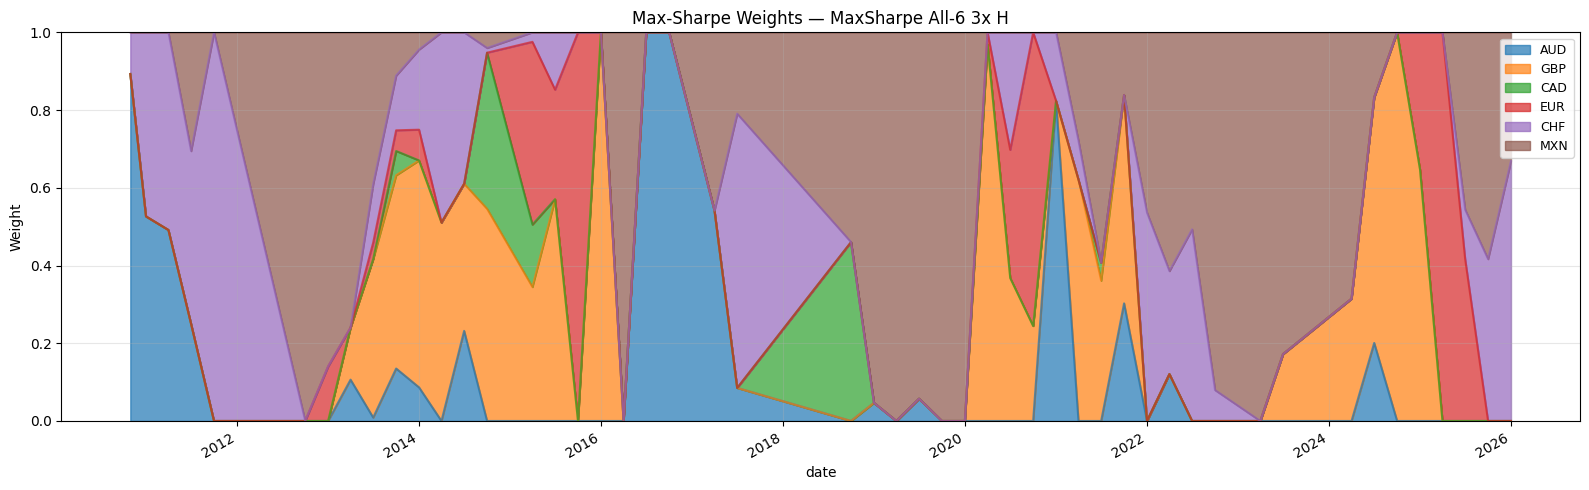

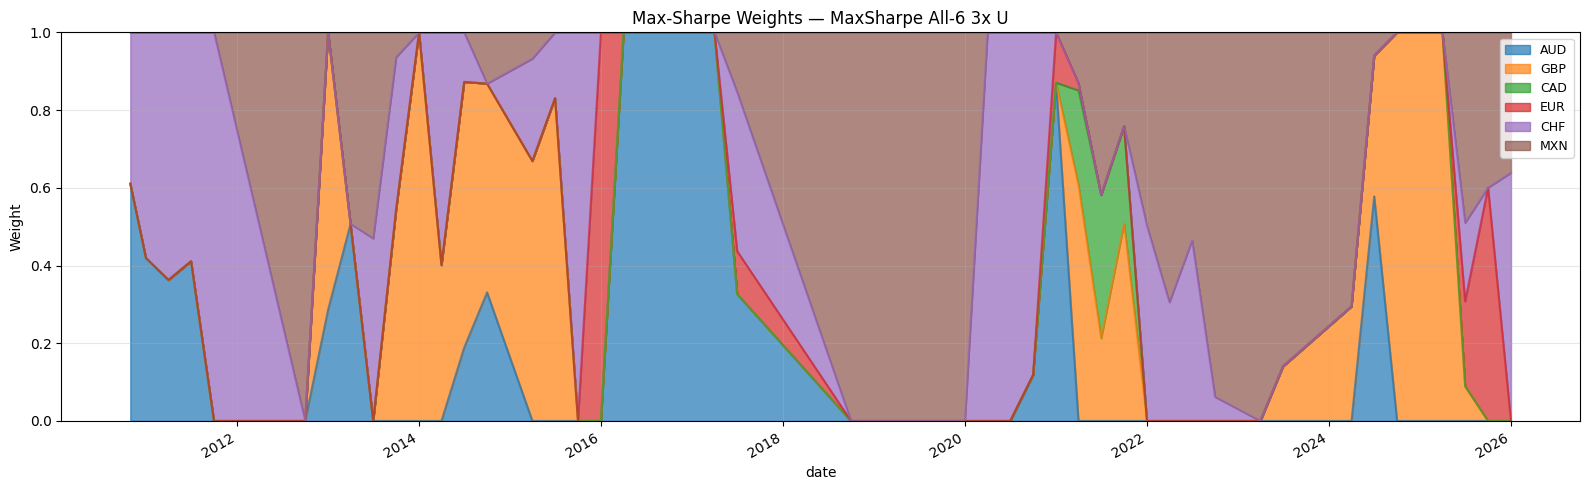

In [27]:
# Plot max-Sharpe weights evolution
for tag in ['MaxSharpe All-6 3x H', 'MaxSharpe All-6 3x U']:
    if tag in ms_weights and ms_weights[tag] is not None:
        wts = ms_weights[tag].fillna(0)
        fig, ax = plt.subplots(1, 1, figsize=(16, 5))
        wts.plot.area(ax=ax, alpha=0.7)
        ax.set_title(f'Max-Sharpe Weights — {tag}')
        ax.set_ylabel('Weight')
        ax.legend(loc='upper right', fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 8. Regime Analysis

Split sample into risk-on (carry pairs appreciating) and risk-off (carry pairs declining) using the average carry return over 60 days as a regime indicator.

Risk-on days:  3202 (65.6%)
Risk-off days: 1619 (33.2%)


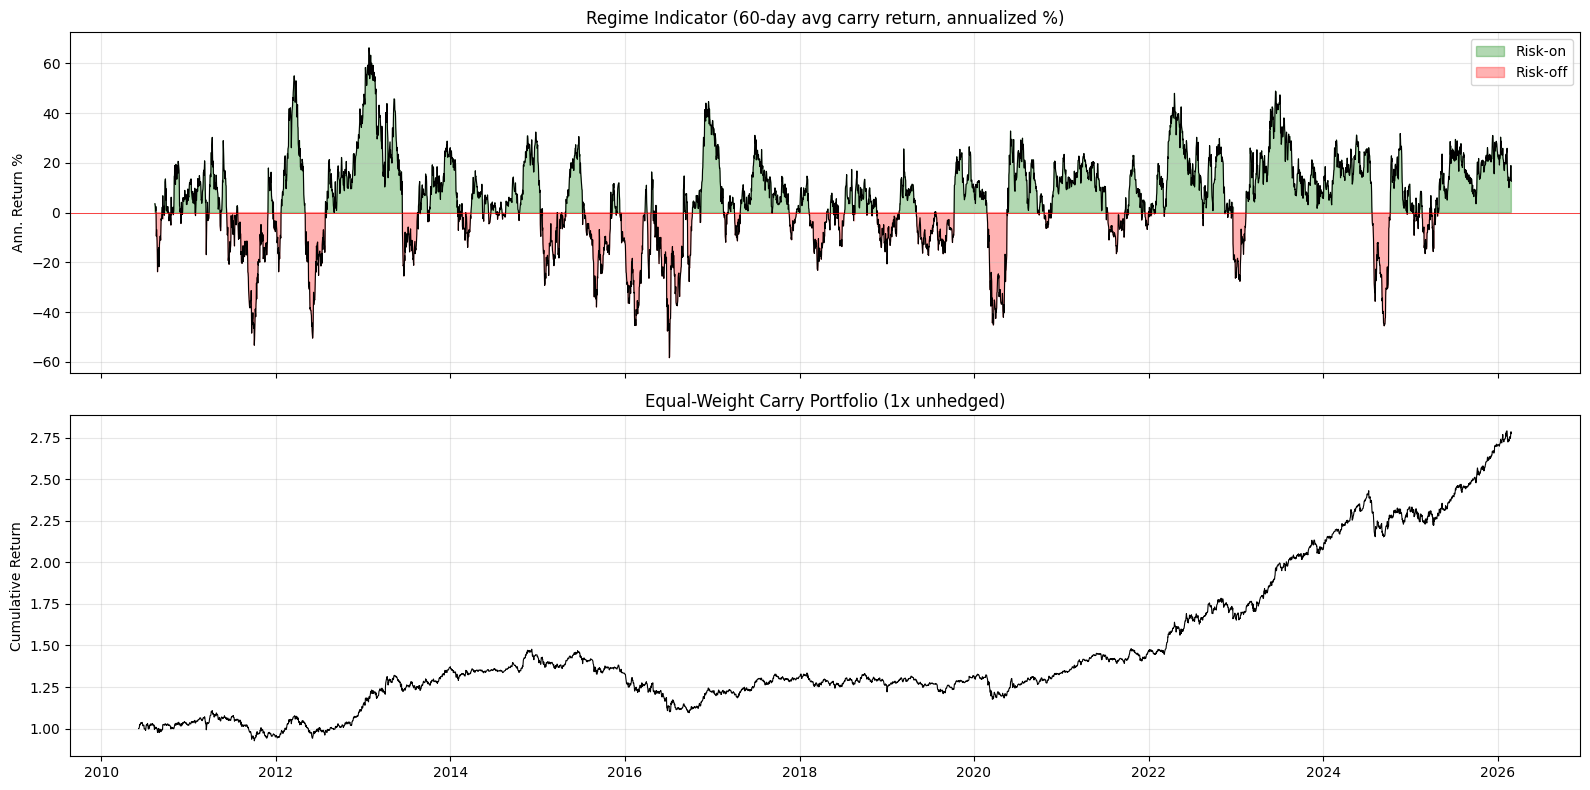

In [28]:
# Regime indicator: 60-day average of equal-weight carry return
ew_daily_ret = ret_1x_u.mean(axis=1)
regime_signal = ew_daily_ret.rolling(60).mean()
risk_on = regime_signal > 0
risk_off = regime_signal <= 0

print(f'Risk-on days:  {risk_on.sum()} ({risk_on.mean()*100:.1f}%)')
print(f'Risk-off days: {risk_off.sum()} ({risk_off.mean()*100:.1f}%)')

# Plot regime indicator
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax1.plot(ew_daily_ret.rolling(60).mean().index,
         ew_daily_ret.rolling(60).mean() * 252 * 100, color='black', linewidth=0.8)
ax1.axhline(0, color='red', linewidth=0.5)
ax1.fill_between(regime_signal.index,
                 regime_signal.values * 252 * 100,
                 0, where=regime_signal > 0, alpha=0.3, color='green', label='Risk-on')
ax1.fill_between(regime_signal.index,
                 regime_signal.values * 252 * 100,
                 0, where=regime_signal <= 0, alpha=0.3, color='red', label='Risk-off')
ax1.set_title('Regime Indicator (60-day avg carry return, annualized %)')
ax1.set_ylabel('Ann. Return %')
ax1.legend()
ax1.grid(True, alpha=0.3)

# EW portfolio cumulative return colored by regime
ew_cum = (1 + ew_daily_ret).cumprod()
ax2.plot(ew_cum.index, ew_cum, color='black', linewidth=0.8)
ax2.set_title('Equal-Weight Carry Portfolio (1x unhedged)')
ax2.set_ylabel('Cumulative Return')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Portfolio performance in each regime
# Collect all portfolio variants
all_port_caps = {}
all_port_caps.update(ew_results)
all_port_caps.update(rp_results)
all_port_caps.update(mv_results)
all_port_caps.update(ms_results)

# Focus on key variants
key_variants = [
    'All-6 EW 3x U', 'All-6 EW 3x H',
    'RP All-6 3x U', 'RP All-6 3x H',
    'MinVar All-6 3x U', 'MinVar All-6 3x H',
    'MaxSharpe All-6 3x U', 'MaxSharpe All-6 3x H',
]

print('=' * 110)
print('REGIME ANALYSIS — 3x LEVERAGE')
print('=' * 110)
print(f'{"Portfolio":>35} {"Risk-On Ann%":>14} {"Risk-Off Ann%":>14} {"On Sharpe":>10} {"Off Sharpe":>10} {"Asymmetry":>10}')
print('-' * 110)

for tag in key_variants:
    if tag not in all_port_caps:
        continue
    cap = all_port_caps[tag]
    daily_ret = cap.pct_change().dropna()

    # Align with regime signal
    common_idx = daily_ret.index.intersection(regime_signal.dropna().index)
    dr = daily_ret.loc[common_idx]
    ro = risk_on.loc[common_idx]
    rf = risk_off.loc[common_idx]

    ret_on = dr[ro]
    ret_off = dr[rf]

    ann_on = ret_on.mean() * 252 if len(ret_on) > 0 else 0
    ann_off = ret_off.mean() * 252 if len(ret_off) > 0 else 0
    vol_on = ret_on.std() * np.sqrt(252) if len(ret_on) > 1 else 1
    vol_off = ret_off.std() * np.sqrt(252) if len(ret_off) > 1 else 1
    sharpe_on = ann_on / vol_on if vol_on > 0 else 0
    sharpe_off = ann_off / vol_off if vol_off > 0 else 0
    asymmetry = sharpe_on - sharpe_off

    print(f'{tag:>35} {ann_on*100:>13.2f}% {ann_off*100:>13.2f}% '
          f'{sharpe_on:>10.3f} {sharpe_off:>10.3f} {asymmetry:>+10.3f}')

print('\nPositive asymmetry = better risk-on vs risk-off performance')
print('Hedging should improve asymmetry by reducing risk-off losses')

REGIME ANALYSIS — 3x LEVERAGE
                          Portfolio   Risk-On Ann%  Risk-Off Ann%  On Sharpe Off Sharpe  Asymmetry
--------------------------------------------------------------------------------------------------------------
                      All-6 EW 3x U         47.15%        -42.44%      1.967     -1.416     +3.382
                      All-6 EW 3x H         53.49%        -27.71%      1.985     -0.643     +2.629
                      RP All-6 3x U         45.08%        -42.77%      1.930     -1.493     +3.423
                      RP All-6 3x H         50.23%        -31.78%      1.922     -0.900     +2.823
                  MinVar All-6 3x U         41.95%        -42.41%      1.867     -1.540     +3.407
                  MinVar All-6 3x H         52.75%        -26.18%      1.725     -0.665     +2.390
               MaxSharpe All-6 3x U         55.76%        -44.71%      1.986     -1.290     +3.276
               MaxSharpe All-6 3x H         60.48%        -26.51%  

## 9. Drawdown Analysis

Max drawdown comparison, drawdown duration, conditional drawdown at risk (CDaR), and overlaid drawdown paths.

In [30]:
# Drawdown table for all portfolio variants
print('=' * 130)
print('DRAWDOWN ANALYSIS — ALL PORTFOLIO VARIANTS')
print('=' * 130)
print(f'{"Portfolio":>38} {"MaxDD":>8} {"MaxDD Days":>10} {"Avg DD":>8} {"CDaR 95%":>10} {"Recovery":>10}')
print('-' * 130)

dd_data = {}
for tag in sorted(list(ew_results.keys()) + list(rp_results.keys()) +
                   list(mv_results.keys()) + list(ms_results.keys())):
    if tag in ew_results:
        cap = ew_results[tag]
    elif tag in rp_results:
        cap = rp_results[tag]
    elif tag in mv_results:
        cap = mv_results[tag]
    elif tag in ms_results:
        cap = ms_results[tag]
    else:
        continue

    cap = cap[cap > 0]
    if len(cap) < 252:
        continue

    drawdown = cap / cap.cummax() - 1
    max_dd = drawdown.min()
    avg_dd = drawdown[drawdown < 0].mean() if (drawdown < 0).any() else 0

    # CDaR (95th percentile of drawdowns)
    dd_values = drawdown[drawdown < 0]
    cdar_95 = dd_values.quantile(0.05) if len(dd_values) > 10 else max_dd

    # Max drawdown duration
    in_dd = drawdown < 0
    dd_groups = (~in_dd).cumsum()
    if in_dd.any():
        dd_durations = in_dd.groupby(dd_groups).sum()
        max_dd_days = int(dd_durations.max())
        # Recovery: median drawdown duration
        recovery_median = int(dd_durations[dd_durations > 0].median())
    else:
        max_dd_days = 0
        recovery_median = 0

    dd_data[tag] = {
        'MaxDD': max_dd, 'MaxDD_days': max_dd_days,
        'AvgDD': avg_dd, 'CDaR95': cdar_95, 'Recovery': recovery_median,
    }

    print(f'{tag:>38} {max_dd*100:>7.1f}% {max_dd_days:>10d} {avg_dd*100:>7.1f}% '
          f'{cdar_95*100:>9.1f}% {recovery_median:>9d}d')

DRAWDOWN ANALYSIS — ALL PORTFOLIO VARIANTS
                             Portfolio    MaxDD MaxDD Days   Avg DD   CDaR 95%   Recovery
----------------------------------------------------------------------------------------------------------------------------------
                         All-6 EW 1x H   -24.2%       1768    -6.1%     -16.4%         3d
                         All-6 EW 1x U   -25.9%       2135    -7.7%     -18.2%         3d
                         All-6 EW 3x H   -59.3%       1967   -19.5%     -46.0%         3d
                         All-6 EW 3x U   -62.2%       2271   -24.3%     -50.4%         3d
               Core (AUD+GBP+CAD) 1x H   -24.7%       1604    -6.8%     -17.7%         3d
               Core (AUD+GBP+CAD) 1x U   -26.5%       2268    -8.9%     -20.5%         3d
               Core (AUD+GBP+CAD) 3x H   -61.3%       2126   -21.9%     -50.2%         3d
               Core (AUD+GBP+CAD) 3x U   -66.8%       2410   -27.4%     -56.5%         3d
    Diversified 

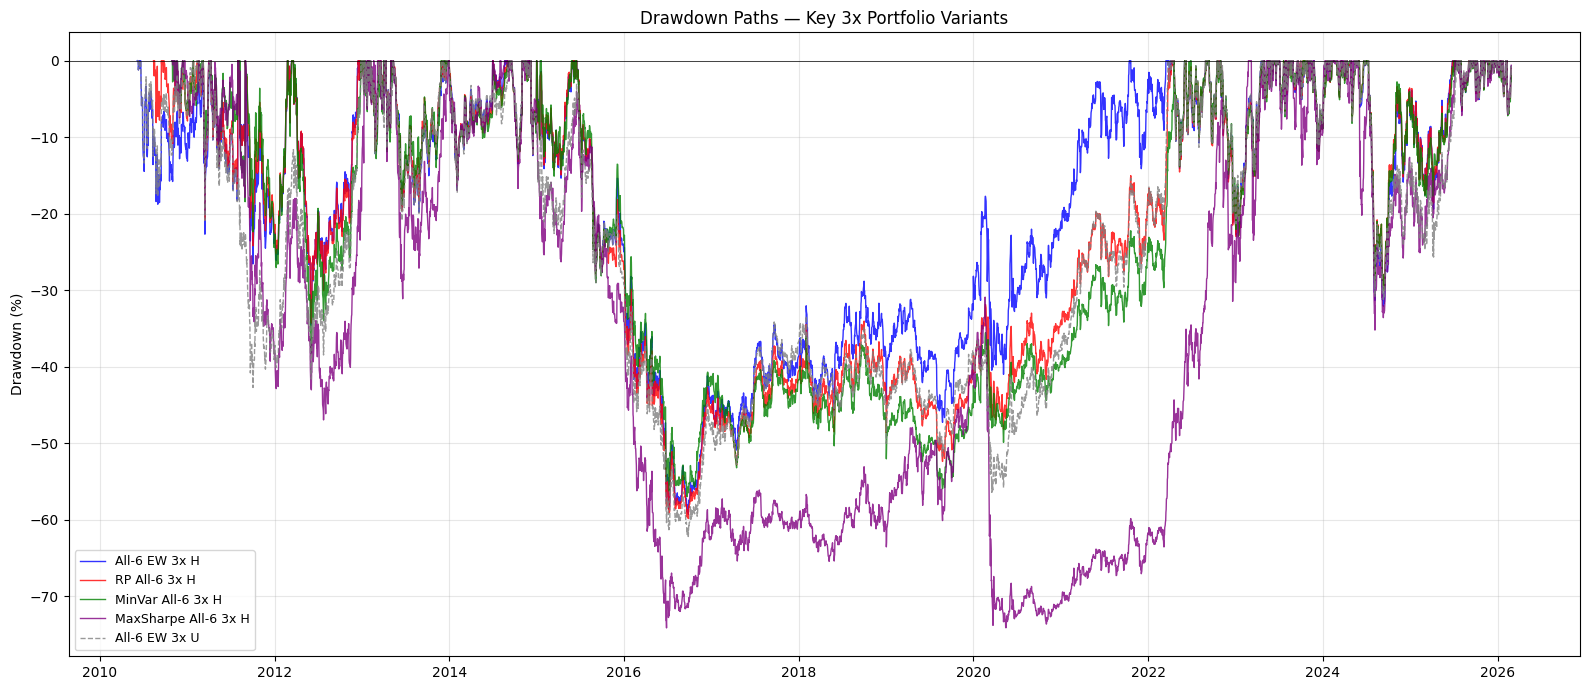

In [31]:
# Plot drawdown paths for key portfolios
key_dd_tags = ['All-6 EW 3x H', 'RP All-6 3x H', 'MinVar All-6 3x H', 'MaxSharpe All-6 3x H',
               'All-6 EW 3x U']

fig, ax = plt.subplots(1, 1, figsize=(16, 7))
dd_colors = ['blue', 'red', 'green', 'purple', 'gray']

for tag, color in zip(key_dd_tags, dd_colors):
    cap = None
    for d in [ew_results, rp_results, mv_results, ms_results]:
        if tag in d:
            cap = d[tag]
            break
    if cap is None:
        continue
    cap = cap[cap > 0]
    drawdown = (cap / cap.cummax() - 1) * 100
    ls = '-' if 'H' in tag else '--'
    ax.plot(drawdown.index, drawdown, color=color, linestyle=ls,
            alpha=0.8, label=tag, linewidth=1)

ax.set_title('Drawdown Paths — Key 3x Portfolio Variants')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 10. Final Comparison Table

All portfolio variants in one comprehensive table. Includes SPY benchmarks for context:
- SPY buy-and-hold: ~11% CAGR, ~0.55 Sharpe
- SPY + puts (Spitznagel structure): ~16% CAGR, ~1.88 Sharpe

In [32]:
# Merge all portfolio results
all_portfolios = {}
all_portfolios.update(ew_results)
all_portfolios.update(rp_results)
all_portfolios.update(mv_results)
all_portfolios.update(ms_results)

# Compute stats for all
rows = []
for tag in sorted(all_portfolios.keys()):
    s = compute_stats(all_portfolios[tag])
    if s:
        s['Portfolio'] = tag
        rows.append(s)

stats_df = pd.DataFrame(rows)
stats_df = stats_df.set_index('Portfolio')

# Sort by Sharpe descending
stats_df = stats_df.sort_values('Sharpe', ascending=False)

print('=' * 155)
print('FINAL COMPARISON — ALL PORTFOLIO VARIANTS (sorted by Sharpe)')
print('=' * 155)
print(f'{"Portfolio":>38} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Win%":>5} {"Total":>7}')
print('-' * 155)

for idx, row in stats_df.iterrows():
    print(f'{idx:>38} {row["CAGR"]*100:>7.2f}% {row["Vol"]*100:>5.1f}% '
          f'{row["Sharpe"]:>7.3f} {row["Sortino"]:>8.3f} {row["Calmar"]:>7.3f} '
          f'{row["MaxDD"]*100:>6.1f}% {int(row["MaxDD_days"]):>7d} '
          f'{row["Skew"]:>6.2f} {row["Kurt"]:>6.1f} {row["Win%"]:>4.0f}% '
          f'{row["Total"]:>6.1f}x')

# Benchmarks
print('-' * 155)
print(f'{"SPY Buy & Hold (approx)":>38} {11.0:>7.2f}% {15.0:>5.1f}% '
      f'{0.55:>7.3f} {"":>8} {"":>7} '
      f'{-34.0:>6.1f}% {"":>7} '
      f'{"":>6} {"":>6} {"":>5} {"":>7}')
print(f'{"SPY + Puts Spitznagel (approx)":>38} {16.0:>7.2f}% {12.0:>5.1f}% '
      f'{1.88:>7.3f} {"":>8} {"":>7} '
      f'{-15.0:>6.1f}% {"":>7} '
      f'{"":>6} {"":>6} {"":>5} {"":>7}')

# Highlight top 5
print('\n--- TOP 5 BY SHARPE ---')
for i, (idx, row) in enumerate(stats_df.head(5).iterrows()):
    print(f'  {i+1}. {idx}: Sharpe {row["Sharpe"]:.3f}, CAGR {row["CAGR"]*100:.2f}%, MaxDD {row["MaxDD"]*100:.1f}%')

FINAL COMPARISON — ALL PORTFOLIO VARIANTS (sorted by Sharpe)
                             Portfolio     CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD DD days   Skew   Kurt  Win%   Total
-----------------------------------------------------------------------------------------------------------------------------------------------------------
             High-Carry (AUD+MXN) 1x H   14.26%  13.8%   1.030    1.643   0.554  -25.7%    1123   6.65  173.9   88%    8.1x
                     MinVar All-6 1x H   10.57%  10.6%   0.993    1.633   0.435  -24.3%    1781   6.58  179.1   88%    4.7x
             High-Carry (AUD+MXN) 3x H   39.94%  41.5%   0.961    1.534   0.631  -63.3%    1304   6.65  173.9   81%  197.5x
    Diversified (AUD+EUR+CHF+MXN) 1x H   11.57%  12.1%   0.955    1.737   0.497  -23.3%    1757  12.78  452.5   88%    5.6x
                         All-6 EW 1x H   10.45%  11.1%   0.939    1.598   0.431  -24.2%    1768   9.47  314.0   88%    4.8x
                         RP All-6 1x H 

## 11. Year-by-Year Returns

Annual returns for the top portfolio variants.

In [33]:
# Pick top portfolio variants for year-by-year
top_tags = list(stats_df.head(4).index)
# Also include EW 3x H and EW 3x U as baselines if not already there
for baseline in ['All-6 EW 3x H', 'All-6 EW 3x U']:
    if baseline not in top_tags and baseline in all_portfolios:
        top_tags.append(baseline)

# Collect yearly returns
yearly_data = {}
for tag in top_tags:
    cap = all_portfolios[tag]
    cap = cap[cap > 0]
    yearly = cap.resample('YE').last().pct_change().dropna()
    yearly_data[tag] = yearly

all_years = sorted(set(y.year for ys in yearly_data.values() for y in ys.index))

# Truncate long names for display
def short_name(tag):
    return tag.replace('(AUD+GBP+CAD)', 'Core').replace('(AUD+EUR+CHF+MXN)', 'Div')[:30]

print('=' * (10 + len(top_tags) * 14))
print('YEAR-BY-YEAR RETURNS — TOP PORTFOLIO VARIANTS')
print('=' * (10 + len(top_tags) * 14))

header = f'{"Year":>6}'
for tag in top_tags:
    header += f'  {short_name(tag):>12}'
print(header)
print('-' * (10 + len(top_tags) * 14))

for year in all_years:
    row = f'{year:>6}'
    for tag in top_tags:
        ys = yearly_data[tag]
        match = ys[ys.index.year == year]
        if len(match) > 0:
            ret = match.iloc[0]
            row += f'  {ret*100:>11.1f}%'
        else:
            row += f'  {"---":>12}'
    print(row)

print('-' * (10 + len(top_tags) * 14))
row = f'{"Avg":>6}'
for tag in top_tags:
    avg = yearly_data[tag].mean()
    row += f'  {avg*100:>11.1f}%'
print(row)

row = f'{"Med":>6}'
for tag in top_tags:
    med = yearly_data[tag].median()
    row += f'  {med*100:>11.1f}%'
print(row)

row = f'{"Win%":>6}'
for tag in top_tags:
    pct = (yearly_data[tag] > 0).mean() * 100
    row += f'  {pct:>11.0f}%'
print(row)

YEAR-BY-YEAR RETURNS — TOP PORTFOLIO VARIANTS
  Year  High-Carry (AUD+MXN) 1x H  MinVar All-6 1x H  High-Carry (AUD+MXN) 3x H  Diversified Div 1x H  All-6 EW 3x H  All-6 EW 3x U
----------------------------------------------------------------------------------------------
  2011         18.4%         16.8%         37.6%         30.1%         49.8%        -23.1%
  2012         23.7%         17.8%         80.2%         18.7%         54.5%         66.4%
  2013         49.4%         35.9%        192.4%         34.0%        131.2%         67.5%
  2014         13.3%         18.1%         39.3%         12.9%         58.7%         11.9%
  2015         -7.7%         -2.3%        -24.7%         -0.7%         -9.9%        -22.2%
  2016         -5.1%         -7.5%        -22.3%         -5.7%        -25.3%        -25.9%
  2017          8.5%          3.3%         23.5%          4.8%          9.3%         20.3%
  2018         12.4%          0.5%         34.6%          1.6%         -0.0%        -13.0%

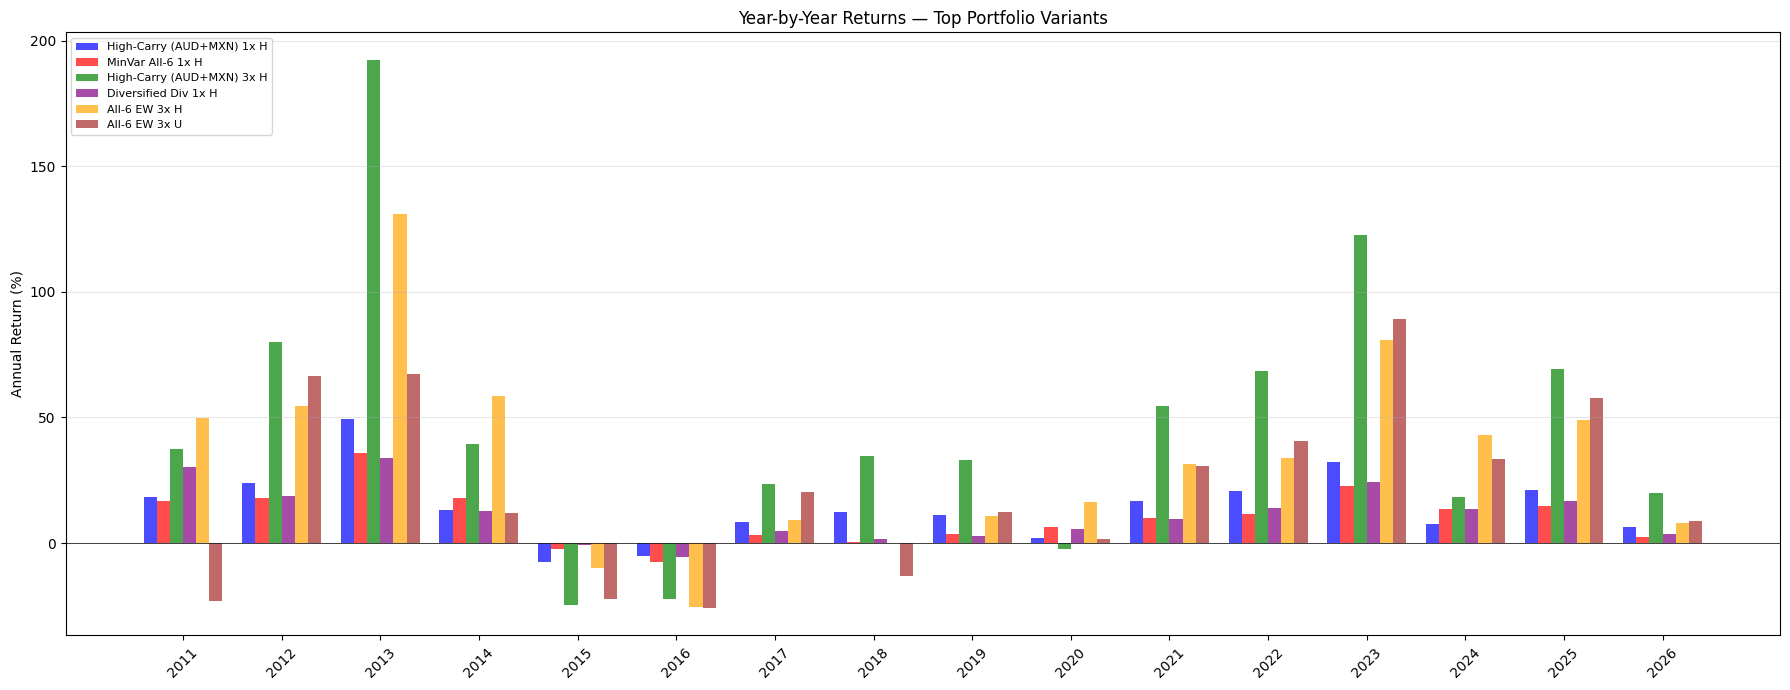

In [34]:
# Plot annual returns as grouped bar chart for top variants
fig, ax = plt.subplots(1, 1, figsize=(18, 7))

n_tags = len(top_tags)
x = np.arange(len(all_years))
width = 0.8 / n_tags
bar_colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']

for i, tag in enumerate(top_tags):
    ys = yearly_data[tag]
    vals = []
    for year in all_years:
        match = ys[ys.index.year == year]
        vals.append(match.iloc[0] * 100 if len(match) > 0 else 0)
    ax.bar(x + i * width - 0.4 + width/2, vals, width,
           label=short_name(tag), color=bar_colors[i % len(bar_colors)], alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(all_years, rotation=45)
ax.set_ylabel('Annual Return (%)')
ax.set_title('Year-by-Year Returns — Top Portfolio Variants')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 12. Conclusions

In [35]:
# Print conclusions based on computed results
# Find best portfolios
best_sharpe = stats_df.iloc[0]
best_calmar = stats_df.sort_values('Calmar', ascending=False).iloc[0]
best_cagr = stats_df.sort_values('CAGR', ascending=False).iloc[0]
lowest_dd = stats_df.sort_values('MaxDD', ascending=False).iloc[0]

# Compare hedged vs unhedged averages
hedged_stats = stats_df[stats_df.index.str.contains(' H')]
unhedged_stats = stats_df[stats_df.index.str.contains(' U')]

print("""
OPTIMAL FX CARRY PORTFOLIO — KEY FINDINGS
==========================================

1. BEST PORTFOLIO BY SHARPE RATIO:""")
print(f'   {best_sharpe.name}')
print(f'   Sharpe: {best_sharpe["Sharpe"]:.3f}, CAGR: {best_sharpe["CAGR"]*100:.2f}%, MaxDD: {best_sharpe["MaxDD"]*100:.1f}%')

print("""
2. PORTFOLIO CONSTRUCTION METHOD RANKING:""")
for method in ['EW', 'RP', 'MinVar', 'MaxSharpe']:
    method_ports = stats_df[stats_df.index.str.contains(method)]
    if len(method_ports) > 0:
        best = method_ports.sort_values('Sharpe', ascending=False).iloc[0]
        print(f'   {method:>10}: best Sharpe = {best["Sharpe"]:.3f} ({best.name})')

print("""
3. HEDGING IMPACT:""")
if len(hedged_stats) > 0 and len(unhedged_stats) > 0:
    print(f'   Avg Sharpe — hedged:   {hedged_stats["Sharpe"].mean():.3f}')
    print(f'   Avg Sharpe — unhedged: {unhedged_stats["Sharpe"].mean():.3f}')
    print(f'   Avg MaxDD  — hedged:   {hedged_stats["MaxDD"].mean()*100:.1f}%')
    print(f'   Avg MaxDD  — unhedged: {unhedged_stats["MaxDD"].mean()*100:.1f}%')
    print(f'   Avg Skew   — hedged:   {hedged_stats["Skew"].mean():.2f}')
    print(f'   Avg Skew   — unhedged: {unhedged_stats["Skew"].mean():.2f}')

print("""
4. vs SPY BENCHMARKS:
   SPY buy & hold:      ~11% CAGR, ~0.55 Sharpe, ~-34% MaxDD
   SPY + puts:          ~16% CAGR, ~1.88 Sharpe, ~-15% MaxDD""")
print(f'   Best carry portfolio: {best_sharpe["CAGR"]*100:.1f}% CAGR, {best_sharpe["Sharpe"]:.2f} Sharpe, {best_sharpe["MaxDD"]*100:.1f}% MaxDD')

print("""
5. PRACTICAL RECOMMENDATIONS:
   a) For conservative investors: MinVar or Risk-Parity hedged at 1x
      - Lowest drawdowns, most stable weights
   b) For moderate risk: EW All-6 hedged at 1x or Risk-Parity at 3x
      - Good balance of return and risk
   c) For aggressive: MaxSharpe or EW hedged at 3x
      - Highest returns but larger drawdowns
   d) Hedging is almost always worth the cost:
      - Reduces max drawdown, improves skew
      - Small drag on CAGR but large improvement in tail risk
   e) Diversification across 6 pairs is better than concentrating:
      - Reduces idiosyncratic risk (GBP Brexit, CHF floor removal)
      - MXN adds EM premium but starts later (2013)
   f) Risk-parity naturally underweights MXN/CHF (highest vol pairs)
      - More stable than equal-weight in stressed markets
""")


OPTIMAL FX CARRY PORTFOLIO — KEY FINDINGS

1. BEST PORTFOLIO BY SHARPE RATIO:
   High-Carry (AUD+MXN) 1x H
   Sharpe: 1.030, CAGR: 14.26%, MaxDD: -25.7%

2. PORTFOLIO CONSTRUCTION METHOD RANKING:
           EW: best Sharpe = 0.939 (All-6 EW 1x H)
           RP: best Sharpe = 0.922 (RP All-6 1x H)
       MinVar: best Sharpe = 0.993 (MinVar All-6 1x H)
    MaxSharpe: best Sharpe = 0.872 (MaxSharpe All-6 1x U)

3. HEDGING IMPACT:
   Avg Sharpe — hedged:   0.879
   Avg Sharpe — unhedged: 0.707
   Avg MaxDD  — hedged:   -43.7%
   Avg MaxDD  — unhedged: -44.9%
   Avg Skew   — hedged:   9.63
   Avg Skew   — unhedged: -0.34

4. vs SPY BENCHMARKS:
   SPY buy & hold:      ~11% CAGR, ~0.55 Sharpe, ~-34% MaxDD
   SPY + puts:          ~16% CAGR, ~1.88 Sharpe, ~-15% MaxDD
   Best carry portfolio: 14.3% CAGR, 1.03 Sharpe, -25.7% MaxDD

5. PRACTICAL RECOMMENDATIONS:
   a) For conservative investors: MinVar or Risk-Parity hedged at 1x
      - Lowest drawdowns, most stable weights
   b) For moderate ri